# TalkEx v2: Classificação de Intenções por Turno via Recuperação de Exemplares

**TCC — Centro de Competências Embrapii em Tecnologias Imersivas (AKCIT)**

Cauê C. Leão &bull; Paulo H. V. Nascimento &bull; Suele S. F. Sousa

---

### Pergunta de pesquisa

> *Como a classificação por similaridade semântica no nível do turno, combinando recuperação lexical (BM25),
> embeddings multilíngues e regras determinísticas, pode classificar intenções em conversas de atendimento
> ao cliente em português brasileiro — com taxonomia dinâmica definida pela equipe de negócio?*

### Hipóteses

| | Hipótese | Métrica principal |
|:---:|:---|:---|
| **H1** | Recuperação híbrida (BM25 + embeddings) supera paradigmas isolados | MRR + Macro-F1 |
| **H2** | Embedding KNN supera BM25 KNN na classificação por turno | Macro-F1 |
| **H3** | Regras determinísticas complementam classificação por similaridade | Macro-F1 |
| **H4** | Cascata multi-paradigma (Rules → BM25 → Embeddings) melhora F1 com custo crescente | Macro-F1 + tempo |

## Arquitetura do TalkEx v2

```
┌─────────────┐    ┌──────────────┐    ┌──────────────────┐    ┌──────────────┐
│  Conversas   │───▶│ Segmentação  │───▶│  Turnos          │───▶│  Embeddings  │
│  PT-BR       │    │ de Turnos    │    │  individuais     │    │  384 dims    │
└─────────────┘    └──────────────┘    └──────────────────┘    └──────┬───────┘
                                                                      │
                    ┌──────────────┐    ┌──────────────────┐          │
                    │  Classificação│◀──│ Banco de         │◀─── Exemplares por
                    │  por turno   │    │ Exemplares (KNN) │     intenção
                    └──────┬───────┘    └──────────────────┘
                           │
               ┌───────────┼───────────┐
               │           │           │
          ┌────▼────┐ ┌────▼────┐ ┌────▼────┐
          │ Regras  │ │  BM25   │ │Embedding│
          │ (exato) │ │  KNN    │ │  KNN    │
          └─────────┘ └─────────┘ └─────────┘
```

| Componente | Tecnologia | Referência |
|:---|:---|:---|
| Embeddings | paraphrase-multilingual-MiniLM-L12-v2 (congelado, 384d) | Reimers & Gurevych, 2019 |
| Recuperação lexical | BM25 (Okapi) | Robertson et al., 1996 |
| Classificação | KNN por similaridade (voto ponderado por distância) | Cover & Hart, 1967 |
| Regras | 10 regras declarativas (léxico, regex, contextual) | — |
| Fusão híbrida | Linear (α·sem + (1−α)·lex) e RRF | Rayo et al., 2025 |

### v1 vs v2

| Aspecto | v1 | v2 |
|:---|:---|:---|
| Unidade de classificação | Janela de 5 turnos | Turno individual |
| Classificador | LightGBM (397 features extraídas) | KNN por similaridade (384d embeddings) |
| Taxonomia | 8 classes fixas no código | Dinâmica — definida por exemplares |
| Nova classe | Requer retreinamento | Adicionar exemplares (zero-shot) |

## Protocolo Experimental

| Parâmetro | Valor |
|:---|:---|
| **Dataset** | 2.120 conversas (676 originais + 1.444 sintéticas via Claude Sonnet) — HuggingFace |
| **Unidade** | Turno individual (customer-only para classificação) |
| **Classificador** | KNN por similaridade semântica (voto ponderado) |
| **Seeds** | [13, 42, 123, 2024, 999] |
| **Splits** | 70/15/15% estratificados por intenção, nível da conversa |
| **Teste estatístico** | Wilcoxon signed-rank (α=0,05) |
| **Intervalo de confiança** | Bootstrap 95% (10.000 reamostras) |
| **Effect size** | Correlação rank-biserial (r_rb) |
| **Infraestrutura** | Google Colab, GPU Tesla T4 |

---
# 1. Setup e Dados

In [1]:
# Detectar ambiente
import os
IN_COLAB = 'COLAB_GPU' in os.environ or 'GOOGLE_COLAB' in os.environ.get('GCS_READ_CACHE_BLOCK_SIZE', '')

if IN_COLAB:
    print("🔧 Ambiente: Google Colab")
    !pip install -q sentence-transformers rank-bm25 datasets scikit-learn numpy pandas matplotlib seaborn
else:
    print("🔧 Ambiente: Local")

import warnings
warnings.filterwarnings('ignore')

🔧 Ambiente: Google Colab


In [2]:
import json
import time
import re
import unicodedata
from collections import Counter, defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import StratifiedShuffleSplit
from scipy import stats as scipy_stats

try:
    from sentence_transformers import SentenceTransformer
    HAS_SBERT = True
except ImportError:
    HAS_SBERT = False
    print("⚠️ sentence-transformers não disponível")

# Detecção de GPU
try:
    import torch
    GPU_AVAILABLE = torch.cuda.is_available()
    GPU_NAME = torch.cuda.get_device_name(0) if GPU_AVAILABLE else 'N/A'
except ImportError:
    GPU_AVAILABLE = False
    GPU_NAME = 'N/A'

print(f"NumPy: {np.__version__}")
print(f"SentenceTransformer: {HAS_SBERT}")
print(f"GPU disponível: {GPU_AVAILABLE} ({GPU_NAME})")

NumPy: 2.0.2
SentenceTransformer: True
GPU disponível: True (Tesla T4)


In [3]:
# === CARREGAMENTO DO DATASET ===
import logging
logging.getLogger("huggingface_hub").setLevel(logging.ERROR)

from datasets import load_dataset

HF_REPO = "paulohenriquevn/talkex-augmented-pt-br"

print(f"📥 Carregando corpus de {HF_REPO}...")
ds = load_dataset(HF_REPO, split="train")
print(f"   {len(ds)} registros carregados")

df_original = pd.DataFrame(ds)

if '_synthetic' not in df_original.columns:
    df_original['_synthetic'] = False

n_orig = len(df_original[~df_original['_synthetic']])
n_syn = len(df_original[df_original['_synthetic']])

print(f"\n✅ Corpus carregado (custo: $0)")
print(f"   Originais:  {n_orig}")
print(f"   Sintéticas: {n_syn}")
print(f"   Total:      {len(df_original)}")

print(f"\n📊 Distribuição por intenção:")
print(df_original['intent'].value_counts().to_string())

📥 Carregando corpus de paulohenriquevn/talkex-augmented-pt-br...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/946k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2120 [00:00<?, ? examples/s]

   2120 registros carregados

✅ Corpus carregado (custo: $0)
   Originais:  676
   Sintéticas: 1444
   Total:      2120

📊 Distribuição por intenção:
intent
compra             265
reclamacao         265
cancelamento       265
duvida_produto     265
saudacao           265
elogio             265
suporte_tecnico    265
duvida_servico     265


In [4]:
# Taxonomia de 8 classes de intenção
INTENT_TAXONOMY = [
    "cancelamento",
    "reclamacao",
    "suporte_tecnico",
    "compra",
    "duvida_produto",
    "duvida_servico",
    "saudacao",
    "elogio",
]

NUM_CLASSES = len(INTENT_TAXONOMY)
print(f"📋 Taxonomia: {NUM_CLASSES} classes de intenção")
for i, intent in enumerate(INTENT_TAXONOMY, 1):
    print(f"   {i}. {intent}")


📋 Taxonomia: 8 classes de intenção
   1. cancelamento
   2. reclamacao
   3. suporte_tecnico
   4. compra
   5. duvida_produto
   6. duvida_servico
   7. saudacao
   8. elogio


In [5]:
# === SEPARAÇÃO: CONVERSAS ORIGINAIS vs SINTÉTICAS ===
# Para avaliação robusta, marcamos quais conversas são sintéticas.
# O test set pode ser filtrado para avaliar exclusivamente em dados reais.

original_conv_ids = set(df_original[~df_original['_synthetic']]['conv_id'].values)
synthetic_conv_ids = set(df_original[df_original['_synthetic']]['conv_id'].values)

print(f"📊 Corpus:")
print(f"   Originais:  {len(original_conv_ids)} conversas")
print(f"   Sintéticas: {len(synthetic_conv_ids)} conversas")
print(f"   Total:      {len(original_conv_ids) + len(synthetic_conv_ids)}")
print(f"\n   IDs originais: prefixo 'conv_'")
print(f"   IDs sintéticas: prefixo 'syn_'")

📊 Corpus:
   Originais:  676 conversas
   Sintéticas: 1444 conversas
   Total:      2120

   IDs originais: prefixo 'conv_'
   IDs sintéticas: prefixo 'syn_'


---
# 2. Pipeline de Processamento

**Segmentação** → parsing `[customer]`/`[agent]` → **Turnos individuais** → **Normalização Unicode** (NFD)

In [6]:
# === SEGMENTAÇÃO DE TURNOS ===

SPEAKER_PATTERN = re.compile(r"\[(customer|agent)\]", re.IGNORECASE)


def segment_turns(text: str) -> list[dict]:
    """Segmenta texto em turnos baseado em marcadores [customer]/[agent]."""
    turns = []
    parts = SPEAKER_PATTERN.split(text)

    i = 0
    while i < len(parts):
        if i + 1 < len(parts) and SPEAKER_PATTERN.match(f"[{parts[i]}]"):
            speaker = parts[i].lower()
            content = parts[i + 1].strip() if i + 1 < len(parts) else ""
            if content:
                turns.append({"speaker": speaker, "text": content})
            i += 2
        else:
            content = parts[i].strip()
            if content and not SPEAKER_PATTERN.match(f"[{content}]"):
                turns.append({"speaker": "customer", "text": content})
            i += 1

    return turns


def extract_turn_records(conv_id, intent, turns):
    """Extrai registros individuais por turno com metadados."""
    records = []
    for t_idx, turn in enumerate(turns):
        records.append({
            "conv_id": conv_id,
            "turn_idx": t_idx,
            "speaker": turn["speaker"],
            "text": turn["text"],
            "intent": intent,
            "position": t_idx / max(len(turns) - 1, 1),
            "n_turns_total": len(turns),
        })
    return records


# Teste
sample_text = "[customer] Boa tarde, quero cancelar meu plano. [agent] Posso ajudar com isso. [customer] Sim, estou insatisfeito."
turns = segment_turns(sample_text)
records = extract_turn_records("test", "cancelamento", turns)
print(f"Turnos: {len(turns)}")
for r in records:
    print(f"  Turn {r['turn_idx']}: [{r['speaker']}] {r['text'][:50]}...")

Turnos: 3
  Turn 0: [customer] Boa tarde, quero cancelar meu plano....
  Turn 1: [agent] Posso ajudar com isso....
  Turn 2: [customer] Sim, estou insatisfeito....


In [7]:
# === NORMALIZAÇÃO UNICODE ===

def strip_accents(text: str) -> str:
    """NFD para remoção de diacríticos no matching lexical."""
    nfd = unicodedata.normalize("NFD", text)
    return "".join(c for c in nfd if unicodedata.category(c) != "Mn")


def normalize_for_matching(text: str) -> str:
    """Normaliza para comparação lexical: lowercase + remoção de acentos."""
    return strip_accents(text.lower())


# Teste
assert normalize_for_matching("Não") == "nao"
assert normalize_for_matching("café") == "cafe"
print("✅ Normalização funcionando corretamente")

✅ Normalização funcionando corretamente


## 3. Representação: Embeddings por Turno

No v2, cada turno é representado **diretamente** pelo seu embedding de 384 dimensões — sem feature engineering.

| | v1 | v2 |
|:---|:---|:---|
| Representação | 397 features (384 emb + 7 lex + 4 struct + 2 rules) | 384 dims (embedding puro) |
| Feature engineering | Manual (7 lexicais, 4 estruturais) | Nenhuma |
| Input do classificador | Vetor concatenado → LightGBM | Embedding → KNN por similaridade |
| Regras | Features binárias no vetor | Estágio separado (pré/pós-filtro) |

In [8]:
# === EMBEDDING GENERATION ===

EMBEDDING_MODEL_NAME = "paraphrase-multilingual-MiniLM-L12-v2"
EMBEDDING_DIM = 384

if HAS_SBERT:
    print(f"🔄 Carregando modelo: {EMBEDDING_MODEL_NAME}...")
    start = time.time()
    embedding_model = SentenceTransformer(EMBEDDING_MODEL_NAME)
    elapsed = time.time() - start
    print(f"✅ Modelo carregado em {elapsed:.1f}s")
    print(f"   Dimensões: {embedding_model.get_sentence_embedding_dimension()}")
else:
    embedding_model = None
    print("⚠️ Modelo de embeddings não disponível — usando vetores aleatórios para demonstração")


def generate_embeddings(texts: list[str], batch_size: int = 64) -> np.ndarray:
    """Gera embeddings para uma lista de textos."""
    if embedding_model is not None:
        embeddings = embedding_model.encode(
            texts,
            batch_size=batch_size,
            show_progress_bar=len(texts) > 100,
            normalize_embeddings=True,  # L2 normalization
        )
        return np.array(embeddings, dtype=np.float32)
    else:
        # Fallback determinístico para demo sem GPU
        rng = np.random.default_rng(42)
        embs = rng.standard_normal((len(texts), EMBEDDING_DIM)).astype(np.float32)
        norms = np.linalg.norm(embs, axis=1, keepdims=True)
        return embs / norms


🔄 Carregando modelo: paraphrase-multilingual-MiniLM-L12-v2...


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ Modelo carregado em 8.2s
   Dimensões: 384


In [9]:
# === EXTRAÇÃO DE FEATURES LEXICAIS ===

def extract_lexical_features(text: str) -> dict[str, float]:
    """Extrai 7 features lexicais de um texto."""
    chars = len(text)
    words = text.split()
    n_words = len(words)
    avg_word_len = np.mean([len(w) for w in words]) if words else 0.0
    questions = text.count("?")
    exclamations = text.count("!")
    upper_ratio = sum(1 for c in text if c.isupper()) / max(chars, 1)
    digit_ratio = sum(1 for c in text if c.isdigit()) / max(chars, 1)

    return {
        "char_count": float(chars),
        "word_count": float(n_words),
        "avg_word_length": float(avg_word_len),
        "question_count": float(questions),
        "exclamation_count": float(exclamations),
        "uppercase_ratio": float(upper_ratio),
        "digit_ratio": float(digit_ratio),
    }


# === EXTRAÇÃO DE FEATURES ESTRUTURAIS ===
# Considera a presença de customer/agent, número de turnos, diversidade de falantes
def extract_structural_features(window: dict) -> dict[str, float]:
    """Extrai 4 features estruturais de uma janela de contexto."""
    speakers = set(t["speaker"] for t in window["turns"])
    return {
        "is_customer": 1.0 if "customer" in speakers else 0.0,
        "is_agent": 1.0 if "agent" in speakers else 0.0,
        "turn_count": float(window["turn_count"]),
        "speaker_count": float(len(speakers)),
    }


print("✅ Extratores de features definidos")
print(f"   Lexicais: 7 features")
print(f"   Estruturais: 4 features")
print(f"   Embeddings: {EMBEDDING_DIM} features")
print(f"   Regras: 2 features")
print(f"   Total: {7 + 4 + EMBEDDING_DIM + 2} features")


✅ Extratores de features definidos
   Lexicais: 7 features
   Estruturais: 4 features
   Embeddings: 384 features
   Regras: 2 features
   Total: 397 features


In [10]:
# === MOTOR DE REGRAS DECLARATIVO ===
# 10 regras definidas em formato declarativo (dicionários Python)
# com 3 famílias de predicados: léxico (keyword matching),
# padrão (regex) e contextual (occurs_after, repeated).
# Cada regra é avaliada contra o texto normalizado e retorna
# features binárias (0.0/1.0) para alimentar o classificador.

RULES = [
    {
        "rule_id": "rule_cancel",
        "intent": "cancelamento",
        "type": "lexical",
        "keywords": ["cancelar", "cancelamento", "cancela", "desistir",
                     "encerrar contrato", "rescindir", "cancelei", "cancele",
                     "quero cancelar", "desisto"],
    },
    {
        "rule_id": "rule_complaint",
        "intent": "reclamacao",
        "type": "lexical",
        "keywords": ["reclamacao", "reclamar", "reclamando", "absurdo",
                     "inadmissivel", "procon", "anatel", "reclame aqui",
                     "ouvidoria", "insatisfeito", "revoltado", "indignado",
                     "palhacada", "vergonha", "descaso"],
    },
    {
        "rule_id": "rule_support",
        "intent": "suporte_tecnico",
        "type": "lexical",
        "keywords": ["nao funciona", "nao esta funcionando", "problema tecnico",
                     "erro", "bug", "travou", "travando", "nao conecta",
                     "sem sinal", "caiu a conexao", "nao carrega", "tela azul",
                     "resetar", "reiniciar", "configurar", "instalar", "atualizar"],
    },
    {
        "rule_id": "rule_purchase",
        "intent": "compra",
        "type": "lexical",
        "keywords": ["quero comprar", "como compro", "onde compro", "preco", "valor",
                     "quanto custa", "pagamento", "parcela", "desconto", "promocao",
                     "carrinho", "finalizar compra", "pedido", "comprei", "adquirir", "contratar"],
    },
    {
        "rule_id": "rule_product_question",
        "intent": "duvida_produto",
        "type": "lexical",
        "keywords": ["especificacao", "caracteristica", "funcionalidade",
                     "como funciona", "garantia", "manual", "compativel",
                     "tamanho", "modelo", "versao", "cor", "ficha tecnica",
                     "capacidade", "dimensao"],
    },
    {
        "rule_id": "rule_service_question",
        "intent": "duvida_servico",
        "type": "lexical",
        "keywords": ["horario de funcionamento", "prazo de entrega", "como funciona o servico",
                     "politica de troca", "devolver", "troca", "reembolso", "frete",
                     "entrega", "disponibilidade", "agendamento", "agendar",
                     "prazo", "como faco para"],
    },
    {
        "rule_id": "rule_greeting",
        "intent": "saudacao",
        "type": "regex",
        "pattern": r"\b(oi|ola|bom dia|boa tarde|boa noite|hey|hello|tudo bem|e ai)\b",
    },
    {
        "rule_id": "rule_praise",
        "intent": "elogio",
        "type": "lexical",
        "keywords": ["parabens", "excelente", "otimo atendimento", "muito bom",
                     "obrigado", "agradeco", "satisfeito", "maravilhoso",
                     "nota 10", "recomendo", "adorei", "amei", "impecavel", "top"],
    },
    {
        "rule_id": "rule_escalated_cancel",
        "intent": "cancelamento",
        "type": "contextual_occurs_after",
        "first": "problema",
        "second": "cancelar",
    },
    {
        "rule_id": "rule_repeated_error",
        "intent": "suporte_tecnico",
        "type": "contextual_repeated",
        "keyword": "erro",
        "min_count": 2,
    },
]


def evaluate_rules(text: str) -> dict[str, float]:
    """Avalia todas as regras contra um texto. Retorna features binárias + intent predictions."""
    normalized = normalize_for_matching(text)
    results = {}

    for rule in RULES:
        matched = False
        rule_id = rule["rule_id"]

        if rule["type"] == "lexical":
            for kw in rule["keywords"]:
                if normalize_for_matching(kw) in normalized:
                    matched = True
                    break

        elif rule["type"] == "regex":
            if re.search(rule["pattern"], normalized):
                matched = True

        elif rule["type"] == "contextual_occurs_after":
            first_pos = normalized.find(normalize_for_matching(rule["first"]))
            second_pos = normalized.find(normalize_for_matching(rule["second"]))
            if first_pos >= 0 and second_pos > first_pos:
                matched = True

        elif rule["type"] == "contextual_repeated":
            kw = normalize_for_matching(rule["keyword"])
            if normalized.count(kw) >= rule["min_count"]:
                matched = True

        results[rule_id] = 1.0 if matched else 0.0

    return results


# Teste
test_text = "Quero cancelar meu plano, estou muito insatisfeito com o serviço"
rule_results = evaluate_rules(test_text)
matched = {k: v for k, v in rule_results.items() if v > 0}
print(f"Texto: \"{test_text}\"")
print(f"Regras disparadas: {matched}")


Texto: "Quero cancelar meu plano, estou muito insatisfeito com o serviço"
Regras disparadas: {'rule_cancel': 1.0, 'rule_complaint': 1.0, 'rule_praise': 1.0}


In [11]:
# === ESTATÍSTICAS DESCRITIVAS DO CORPUS ===

print("📊 Estatísticas descritivas do corpus")
print("=" * 50)

valid = df_original[df_original['intent'].isin(INTENT_TAXONOMY)]
print(f"   Conversas válidas: {len(valid)}")
print(f"   Originais: {len(valid[~valid['_synthetic']])}")
print(f"   Sintéticas: {len(valid[valid['_synthetic']])}")

print(f"\n📊 Distribuição por classe:")
for intent in INTENT_TAXONOMY:
    n = len(valid[valid['intent'] == intent])
    n_orig = len(valid[(valid['intent'] == intent) & (~valid['_synthetic'])])
    n_syn = n - n_orig
    print(f"   {intent:20s}: {n:4d} ({n_orig} originais, {n_syn} sintéticas)")

# Estatísticas de turnos (preview — números exatos após processamento)
sample_turns_per_conv = []
for _, row in valid.head(100).iterrows():
    t = segment_turns(str(row['text']))
    sample_turns_per_conv.append(len(t))
    customer_turns = sum(1 for turn in t if turn['speaker'] == 'customer')

print(f"\n📊 Turnos por conversa (amostra de {len(sample_turns_per_conv)}):")
print(f"   Média: {np.mean(sample_turns_per_conv):.1f}")
print(f"   Mediana: {np.median(sample_turns_per_conv):.0f}")
print(f"   Min/Max: {min(sample_turns_per_conv)}/{max(sample_turns_per_conv)}")

📊 Estatísticas descritivas do corpus
   Conversas válidas: 2120
   Originais: 676
   Sintéticas: 1444

📊 Distribuição por classe:
   cancelamento        :  265 (79 originais, 186 sintéticas)
   reclamacao          :  265 (84 originais, 181 sintéticas)
   suporte_tecnico     :  265 (88 originais, 177 sintéticas)
   compra              :  265 (85 originais, 180 sintéticas)
   duvida_produto      :  265 (80 originais, 185 sintéticas)
   duvida_servico      :  265 (87 originais, 178 sintéticas)
   saudacao            :  265 (88 originais, 177 sintéticas)
   elogio              :  265 (85 originais, 180 sintéticas)

📊 Turnos por conversa (amostra de 100):
   Média: 7.9
   Mediana: 8
   Min/Max: 6/8


---
# 4. Preparação do Corpus (nível turno)

In [12]:
# === PREPARAÇÃO DO CORPUS (NÍVEL TURNO) ===

SEEDS = [13, 42, 123, 2024, 999]

print("🔄 Processando corpus — extração de turnos individuais...")
start_time = time.time()

conversations = []
all_turns = []

for idx, row in df_original.iterrows():
    intent = str(row['intent']).lower().strip()
    if intent == 'outros' or intent not in INTENT_TAXONOMY:
        continue

    text = str(row['text'])
    turns = segment_turns(text)

    if len(turns) < 2:
        continue

    conv_record = {
        "conv_id": row['conv_id'],
        "text": row['text'],
        "intent": intent,
        "turns": turns,
        "n_turns": len(turns),
    }
    conversations.append(conv_record)

    turn_records = extract_turn_records(row['conv_id'], intent, turns)
    all_turns.extend(turn_records)

elapsed = time.time() - start_time
n_customer = sum(1 for t in all_turns if t['speaker'] == 'customer')
n_agent = sum(1 for t in all_turns if t['speaker'] == 'agent')

print(f"✅ Corpus processado em {elapsed:.1f}s")
print(f"   Conversas válidas: {len(conversations)}")
print(f"   Turnos totais: {len(all_turns)}")
print(f"   Customer turns: {n_customer}")
print(f"   Agent turns: {n_agent}")
print(f"   Média de turnos/conversa: {len(all_turns)/max(len(conversations),1):.1f}")

# Mapas auxiliares
intents_per_conv = {c["conv_id"]: c["intent"] for c in conversations}

# Distribuição
intent_dist = Counter(c["intent"] for c in conversations)
print(f"\n📊 Distribuição de intenções:")
for intent, count in sorted(intent_dist.items(), key=lambda x: -x[1]):
    print(f"   {intent}: {count} ({100*count/len(conversations):.1f}%)")

🔄 Processando corpus — extração de turnos individuais...
✅ Corpus processado em 0.2s
   Conversas válidas: 2120
   Turnos totais: 16627
   Customer turns: 8579
   Agent turns: 8048
   Média de turnos/conversa: 7.8

📊 Distribuição de intenções:
   compra: 265 (12.5%)
   reclamacao: 265 (12.5%)
   cancelamento: 265 (12.5%)
   duvida_produto: 265 (12.5%)
   saudacao: 265 (12.5%)
   elogio: 265 (12.5%)
   suporte_tecnico: 265 (12.5%)
   duvida_servico: 265 (12.5%)


In [13]:
# === GERAÇÃO DE EMBEDDINGS PARA TODOS OS TURNOS ===

print("🔄 Gerando embeddings para todos os turnos...")
turn_texts = [t["text"] for t in all_turns]

start_time = time.time()
all_embeddings = generate_embeddings(turn_texts)
elapsed = time.time() - start_time

print(f"✅ Embeddings gerados em {elapsed:.1f}s")
print(f"   Shape: {all_embeddings.shape}")
print(f"   Throughput: {len(turn_texts)/elapsed:.0f} turnos/s")

🔄 Gerando embeddings para todos os turnos...


Batches:   0%|          | 0/260 [00:00<?, ?it/s]

✅ Embeddings gerados em 10.6s
   Shape: (16627, 384)
   Throughput: 1564 turnos/s


In [14]:
# === PREPARAÇÃO DOS ARRAYS (CUSTOMER-ONLY) ===

# Arrays completos
y_labels = np.array([t["intent"] for t in all_turns])
conv_ids = np.array([t["conv_id"] for t in all_turns])
turn_speakers = np.array([t["speaker"] for t in all_turns])

# Filtro customer-only para classificação
# Justificativa: turnos de agent são formulaicos ("Como posso ajudar?")
# e carregam pouco sinal de intenção do cliente
customer_mask = turn_speakers == "customer"

X_customer = all_embeddings[customer_mask]      # embeddings dos turnos customer
y_customer = y_labels[customer_mask]            # labels dos turnos customer
conv_ids_customer = conv_ids[customer_mask]     # conv_ids dos turnos customer
texts_customer = np.array(turn_texts)[customer_mask]  # textos dos turnos customer

print(f"📊 Dados para classificação (customer-only):")
print(f"   Turnos customer: {customer_mask.sum()}")
print(f"   Turnos agent (excluídos): {(~customer_mask).sum()}")
print(f"   Embeddings shape: {X_customer.shape}")
print(f"   Labels shape: {y_customer.shape}")

📊 Dados para classificação (customer-only):
   Turnos customer: 8579
   Turnos agent (excluídos): 8048
   Embeddings shape: (8579, 384)
   Labels shape: (8579,)


---
# 5. Classificadores por Recuperação de Exemplares

Três classificadores baseados em recuperação, sem treino de modelo supervisionado:

| Classificador | Representação | Custo | Força |
|:---|:---|:---|:---|
| **BM25 KNN** | Tokens (lexical) | Leve | Correspondência exata de termos |
| **Embedding KNN** | Embedding 384d (semântico) | Pesado | Paráfrases e sinônimos |
| **Hybrid KNN** | Fusão BM25 + Embedding | Pesado | Complementaridade léxico-semântica |

Todos usam **voto ponderado por similaridade** entre os K vizinhos mais próximos no banco de exemplares (conjunto de treino).

In [15]:
# === BM25 IMPLEMENTATION + BM25 KNN CLASSIFIER ===

from rank_bm25 import BM25Okapi


def tokenize_bm25(text: str) -> list[str]:
    """Tokeniza texto para BM25: lowercase + strip accents + split."""
    normalized = normalize_for_matching(text)
    normalized = re.sub(r"[^\w\s]", " ", normalized)
    tokens = normalized.split()
    return [t for t in tokens if len(t) > 1]


# === MÉTRICAS DE RETRIEVAL ===
def reciprocal_rank(relevant_ids: set, retrieved_ids: list) -> float:
    for i, doc_id in enumerate(retrieved_ids, 1):
        if doc_id in relevant_ids:
            return 1.0 / i
    return 0.0


def recall_at_k(relevant_ids: set, retrieved_ids: list, k: int) -> float:
    retrieved_set = set(retrieved_ids[:k])
    if not relevant_ids:
        return 0.0
    return len(relevant_ids & retrieved_set) / len(relevant_ids)


def ndcg_at_k(relevant_ids: set, retrieved_ids: list, k: int) -> float:
    dcg = 0.0
    for i, doc_id in enumerate(retrieved_ids[:k], 1):
        if doc_id in relevant_ids:
            dcg += 1.0 / np.log2(i + 1)
    ideal_dcg = sum(1.0 / np.log2(i + 1) for i in range(1, min(len(relevant_ids), k) + 1))
    return dcg / ideal_dcg if ideal_dcg > 0 else 0.0


def bm25_knn_classify(query_texts, corpus_texts, corpus_labels, k=5):
    """Classifica via BM25 KNN: K vizinhos mais similares por BM25, voto ponderado."""
    corpus_tokenized = [tokenize_bm25(t) for t in corpus_texts]
    bm25 = BM25Okapi(corpus_tokenized)

    predictions = []
    confidences = []

    for q_text in query_texts:
        q_tokens = tokenize_bm25(q_text)
        scores = bm25.get_scores(q_tokens)
        top_k_idx = np.argsort(scores)[::-1][:k]
        top_k_labels = corpus_labels[top_k_idx]
        top_k_scores = scores[top_k_idx]

        label_scores = defaultdict(float)
        for label, score in zip(top_k_labels, top_k_scores):
            label_scores[label] += max(score, 0)

        if label_scores:
            predicted = max(label_scores, key=label_scores.get)
            total = sum(label_scores.values())
            confidence = label_scores[predicted] / total if total > 0 else 0
        else:
            predicted = corpus_labels[0]
            confidence = 0

        predictions.append(predicted)
        confidences.append(confidence)

    return np.array(predictions), np.array(confidences)


print("✅ BM25 KNN classifier implementado")

✅ BM25 KNN classifier implementado


In [16]:
# === EMBEDDING KNN CLASSIFIER ===

def embedding_knn_classify(query_embs, corpus_embs, corpus_labels, k=5):
    """Classifica via Embedding KNN: cosseno (dot product em vetores L2-normalizados), voto ponderado."""
    sim_matrix = query_embs @ corpus_embs.T  # (Q, C)

    predictions = []
    confidences = []

    for q_idx in range(len(query_embs)):
        scores = sim_matrix[q_idx]
        top_k_idx = np.argsort(scores)[::-1][:k]
        top_k_labels = corpus_labels[top_k_idx]
        top_k_scores = scores[top_k_idx]

        label_scores = defaultdict(float)
        for label, score in zip(top_k_labels, top_k_scores):
            label_scores[label] += max(score, 0)

        predicted = max(label_scores, key=label_scores.get)
        total = sum(label_scores.values())
        confidence = label_scores[predicted] / total if total > 0 else 0

        predictions.append(predicted)
        confidences.append(confidence)

    return np.array(predictions), np.array(confidences)


print("✅ Embedding KNN classifier implementado")

✅ Embedding KNN classifier implementado


In [17]:
# === HYBRID KNN + CASCADE CLASSIFIER ===

def hybrid_knn_classify(query_texts, query_embs, corpus_texts, corpus_embs,
                        corpus_labels, k=5, alpha=0.5):
    """Hybrid KNN: fusão linear BM25 + cosseno, voto ponderado."""
    corpus_tokenized = [tokenize_bm25(t) for t in corpus_texts]
    bm25 = BM25Okapi(corpus_tokenized)
    sim_matrix = query_embs @ corpus_embs.T

    predictions = []
    confidences = []

    for q_idx, q_text in enumerate(query_texts):
        q_tokens = tokenize_bm25(q_text)
        bm25_scores = bm25.get_scores(q_tokens)
        bm25_min, bm25_max = bm25_scores.min(), bm25_scores.max()
        bm25_norm = (bm25_scores - bm25_min) / (bm25_max - bm25_min + 1e-8)

        emb_scores = sim_matrix[q_idx]
        emb_min, emb_max = emb_scores.min(), emb_scores.max()
        emb_norm = (emb_scores - emb_min) / (emb_max - emb_min + 1e-8)

        fused = alpha * emb_norm + (1 - alpha) * bm25_norm
        top_k_idx = np.argsort(fused)[::-1][:k]
        top_k_labels = corpus_labels[top_k_idx]
        top_k_scores = fused[top_k_idx]

        label_scores = defaultdict(float)
        for label, score in zip(top_k_labels, top_k_scores):
            label_scores[label] += score

        predicted = max(label_scores, key=label_scores.get)
        total = sum(label_scores.values())
        confidence = label_scores[predicted] / total if total > 0 else 0

        predictions.append(predicted)
        confidences.append(confidence)

    return np.array(predictions), np.array(confidences)


def cascade_classify(query_texts, query_embs, corpus_texts, corpus_embs,
                     corpus_labels, rules_list, k=5, rule_confidence=0.8,
                     bm25_threshold=0.5):
    """Cascata multi-paradigma: Rules → BM25 KNN → Embedding KNN."""
    n = len(query_texts)
    predictions = np.full(n, "", dtype=object)
    confidences = np.zeros(n)
    stages = np.full(n, "", dtype=object)

    # Stage 1: Regras determinísticas
    for i, q_text in enumerate(query_texts):
        rule_res = evaluate_rules(q_text)
        matched_rules = [(r["intent"], rule_res[r["rule_id"]])
                         for r in rules_list if rule_res.get(r["rule_id"], 0) > 0]
        if matched_rules:
            # Contar quantas regras de cada classe dispararam
            intent_counts = defaultdict(int)
            for intent, _ in matched_rules:
                intent_counts[intent] += 1
            best_intent = max(intent_counts, key=intent_counts.get)
            if intent_counts[best_intent] >= 1:
                predictions[i] = best_intent
                confidences[i] = min(intent_counts[best_intent] / len(rules_list), 1.0)
                stages[i] = "rules"

    # Stage 2: BM25 KNN (para não resolvidos)
    unresolved = predictions == ""
    if unresolved.any():
        idx_unresolved = np.where(unresolved)[0]
        texts_ur = [query_texts[i] for i in idx_unresolved]
        preds_bm25, confs_bm25 = bm25_knn_classify(texts_ur, corpus_texts, corpus_labels, k=k)
        for j, idx in enumerate(idx_unresolved):
            if confs_bm25[j] >= bm25_threshold:
                predictions[idx] = preds_bm25[j]
                confidences[idx] = confs_bm25[j]
                stages[idx] = "bm25"

    # Stage 3: Embedding KNN (fallback final)
    still_unresolved = predictions == ""
    if still_unresolved.any():
        idx_still = np.where(still_unresolved)[0]
        embs_ur = query_embs[idx_still]
        preds_emb, confs_emb = embedding_knn_classify(embs_ur, corpus_embs, corpus_labels, k=k)
        for j, idx in enumerate(idx_still):
            predictions[idx] = preds_emb[j]
            confidences[idx] = confs_emb[j]
            stages[idx] = "embedding"

    return predictions, confidences, stages


print("✅ Hybrid KNN + Cascade classifier implementados")

✅ Hybrid KNN + Cascade classifier implementados


## 5.1 Auditoria de Qualidade dos Rótulos (KNN Cross-Validation)

Avaliamos a qualidade dos rótulos usando **Embedding KNN** como classificador de referência.
Para cada seed, treina-se o KNN no train set e prediz-se no test set. Conversas onde o modelo
sistematicamente discorda do rótulo são candidatas a erro de rotulação.

In [18]:
# === AUDITORIA DE RÓTULOS (KNN CROSS-VALIDATION) ===

print("=" * 70)
print("AUDITORIA DE RÓTULOS — KNN Cross-Validation")
print("=" * 70)

K_AUDIT = 5
conv_predictions = {}
conv_true_labels = {}

for seed in SEEDS:
    conv_list = np.array(list(set(conv_ids_customer)))
    conv_intent_list = [intents_per_conv.get(c, "outros") for c in conv_list]

    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=seed)
    train_idx, test_val_idx = next(sss.split(conv_list, conv_intent_list))
    test_val_convs = conv_list[test_val_idx]
    test_val_intents = [conv_intent_list[i] for i in test_val_idx]
    sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.50, random_state=seed)
    val_idx, test_idx = next(sss2.split(test_val_convs, test_val_intents))

    train_convs = set(conv_list[train_idx])
    test_convs_set = set(test_val_convs[test_idx])

    train_mask = np.array([c in train_convs for c in conv_ids_customer])
    test_mask = np.array([c in test_convs_set for c in conv_ids_customer])

    preds, _ = embedding_knn_classify(
        X_customer[test_mask], X_customer[train_mask],
        y_customer[train_mask], k=K_AUDIT)

    # Agregar por conversa (voto majoritário)
    test_cids = conv_ids_customer[test_mask]
    test_labels = y_customer[test_mask]
    conv_preds_agg = {}
    for i, cid in enumerate(test_cids):
        if cid not in conv_preds_agg:
            conv_preds_agg[cid] = []
            conv_true_labels[cid] = test_labels[i]
        conv_preds_agg[cid].append(str(preds[i]))

    for cid, turn_preds in conv_preds_agg.items():
        pred = Counter(turn_preds).most_common(1)[0][0]
        if cid not in conv_predictions:
            conv_predictions[cid] = []
        conv_predictions[cid].append(pred)

# Análise
consistent = discordant = uncertain = 0
for cid, preds_list in conv_predictions.items():
    true_label = conv_true_labels[cid]
    n_agree = sum(1 for p in preds_list if p == true_label)
    ratio = n_agree / len(preds_list)
    if ratio >= 0.5:
        consistent += 1
    elif ratio == 0:
        discordant += 1
    else:
        uncertain += 1

total = consistent + discordant + uncertain
accuracy_cv = consistent / total * 100

print(f"\n📊 Resultado (N={total} conversas):")
print(f"   ✅ Consistentes (KNN concorda ≥50%): {consistent:5d} ({consistent/total*100:.1f}%)")
print(f"   ❌ Discordantes (KNN nunca concorda): {discordant:5d} ({discordant/total*100:.1f}%)")
print(f"   ⚠️  Incertos:                         {uncertain:5d} ({uncertain/total*100:.1f}%)")
print(f"   Acurácia estimada: {accuracy_cv:.1f}%")

AUDITORIA DE RÓTULOS — KNN Cross-Validation

📊 Resultado (N=1189 conversas):
   ✅ Consistentes (KNN concorda ≥50%):   911 (76.6%)
   ❌ Discordantes (KNN nunca concorda):   271 (22.8%)
   ⚠️  Incertos:                             7 (0.6%)
   Acurácia estimada: 76.6%


---
# 6. Resultados Experimentais

Cada hipótese é testada com o mesmo protocolo: 5 seeds, splits 70/15/15 no nível da conversa,
Wilcoxon signed-rank + Bootstrap CI 95%. Classificação no **nível do turno (customer-only)**.

## 6.1 H1: Recuperação Híbrida vs Isolada

> **Hipótese:** A fusão de BM25 (lexical) com similaridade cosseno (semântica) supera cada método isolado em MRR e Macro-F1.

**Método:** Para cada turno de teste, classificamos via KNN usando:
- **BM25 KNN** — K vizinhos mais próximos por BM25
- **Embedding KNN** — K vizinhos mais próximos por cosseno
- **Hybrid KNN** — fusão linear dos scores
- **RRF** — Reciprocal Rank Fusion

In [19]:
# === EXPERIMENTO H1 ===

print("=" * 70)
print("HIPÓTESE H1: RECUPERAÇÃO HÍBRIDA vs ISOLADA")
print("=" * 70)

K_BEST = 5  # será refinado na análise de sensibilidade
TOP_K_RETRIEVAL = 20
results_h1 = {s: {} for s in SEEDS}

for seed in SEEDS:
    conv_list = np.array(list(set(conv_ids_customer)))
    conv_intent_list = [intents_per_conv.get(c, "outros") for c in conv_list]

    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=seed)
    train_idx, test_val_idx = next(sss.split(conv_list, conv_intent_list))
    test_val_convs = conv_list[test_val_idx]
    test_val_intents = [conv_intent_list[i] for i in test_val_idx]
    sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.50, random_state=seed)
    val_idx, test_idx = next(sss2.split(test_val_convs, test_val_intents))

    train_convs = set(conv_list[train_idx])
    test_convs_set = set(test_val_convs[test_idx])

    train_mask = np.array([c in train_convs for c in conv_ids_customer])
    test_mask = np.array([c in test_convs_set for c in conv_ids_customer])

    train_texts = texts_customer[train_mask]
    train_embs = X_customer[train_mask]
    train_labels = y_customer[train_mask]
    test_texts_h1 = texts_customer[test_mask]
    test_embs = X_customer[test_mask]
    test_labels = y_customer[test_mask]

    # BM25 KNN
    preds_bm25, _ = bm25_knn_classify(test_texts_h1, train_texts, train_labels, k=K_BEST)
    f1_bm25 = f1_score(test_labels, preds_bm25, average='macro', zero_division=0)
    results_h1[seed]['BM25-KNN'] = f1_bm25

    # Embedding KNN
    preds_emb, _ = embedding_knn_classify(test_embs, train_embs, train_labels, k=K_BEST)
    f1_emb = f1_score(test_labels, preds_emb, average='macro', zero_division=0)
    results_h1[seed]['Embedding-KNN'] = f1_emb

    # Hybrid KNN (sweep alpha)
    for alpha in [0.3, 0.5, 0.65, 0.8]:
        preds_hyb, _ = hybrid_knn_classify(
            test_texts_h1, test_embs, train_texts, train_embs, train_labels,
            k=K_BEST, alpha=alpha)
        f1_hyb = f1_score(test_labels, preds_hyb, average='macro', zero_division=0)
        results_h1[seed][f'Hybrid-α={alpha}'] = f1_hyb

    print(f"  Seed {seed}: BM25={f1_bm25:.4f}, Emb={f1_emb:.4f}, "
          f"Hybrid-0.5={results_h1[seed]['Hybrid-α=0.5']:.4f}")

# Resultados
print("\n" + "=" * 70)
print("RESULTADOS H1: MACRO-F1 (média ± std)")
print("=" * 70)
df_h1 = pd.DataFrame(results_h1).T
for col in df_h1.columns:
    mean = df_h1[col].mean()
    std = df_h1[col].std()
    print(f"  {col:20s}: {mean:.4f} ± {std:.4f}")

# Teste estatístico
best_hybrid = df_h1[[c for c in df_h1.columns if 'Hybrid' in c]].mean().idxmax()
best_isolated = df_h1[['BM25-KNN', 'Embedding-KNN']].mean().idxmax()
s_hyb = df_h1[best_hybrid].values
s_iso = df_h1[best_isolated].values
diff = s_hyb - s_iso

print(f"\n📊 Teste Estatístico — {best_hybrid} vs {best_isolated}")
nonzero = diff[diff != 0]
if len(nonzero) >= 2:
    stat, p = scipy_stats.wilcoxon(s_hyb, s_iso, alternative="greater")
    n = len(nonzero)
    r_rb = 1 - (2 * stat) / (n * (n + 1) / 2)
    print(f"  W={stat:.1f}, p={p:.6f}, r_rb={r_rb:.4f}")
    print(f"  Significativo: {'SIM ✅' if p < 0.05 else 'NÃO ❌'}")

rng = np.random.default_rng(42)
boot = [np.mean(s_hyb[rng.integers(0,5,5)] - s_iso[rng.integers(0,5,5)]) for _ in range(10000)]
print(f"  Bootstrap CI 95%: [{np.percentile(boot,2.5):.4f}, {np.percentile(boot,97.5):.4f}]")

HIPÓTESE H1: RECUPERAÇÃO HÍBRIDA vs ISOLADA
  Seed 13: BM25=0.5853, Emb=0.5444, Hybrid-0.5=0.6006
  Seed 42: BM25=0.6230, Emb=0.5331, Hybrid-0.5=0.6339
  Seed 123: BM25=0.6218, Emb=0.5275, Hybrid-0.5=0.6136
  Seed 2024: BM25=0.6119, Emb=0.5420, Hybrid-0.5=0.6148
  Seed 999: BM25=0.6017, Emb=0.5295, Hybrid-0.5=0.6095

RESULTADOS H1: MACRO-F1 (média ± std)
  BM25-KNN            : 0.6087 ± 0.0157
  Embedding-KNN       : 0.5353 ± 0.0075
  Hybrid-α=0.3        : 0.6174 ± 0.0116
  Hybrid-α=0.5        : 0.6145 ± 0.0122
  Hybrid-α=0.65       : 0.6068 ± 0.0093
  Hybrid-α=0.8        : 0.5924 ± 0.0064

📊 Teste Estatístico — Hybrid-α=0.3 vs BM25-KNN
  W=15.0, p=0.031250, r_rb=-1.0000
  Significativo: SIM ✅
  Bootstrap CI 95%: [-0.0060, 0.0245]


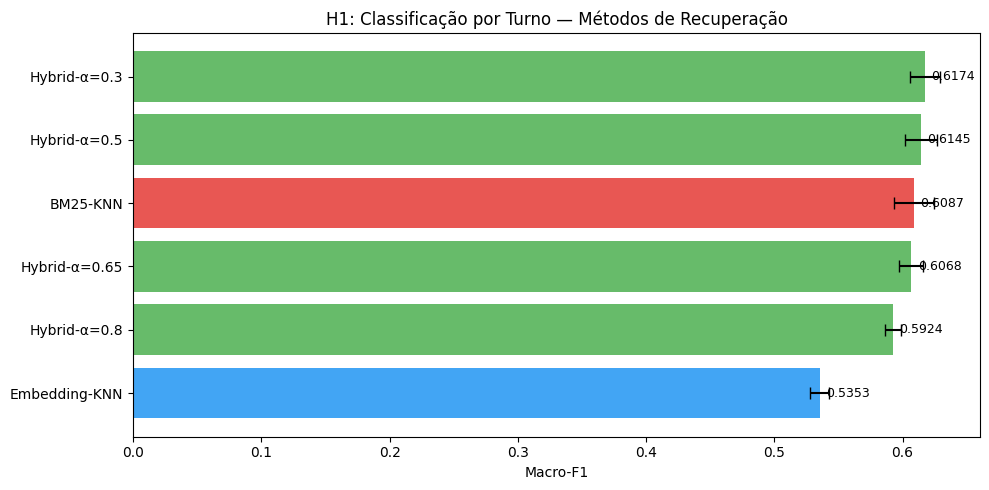

In [20]:
# === VISUALIZAÇÃO H1 ===

fig, ax = plt.subplots(figsize=(10, 5))
methods = list(df_h1.mean().sort_values(ascending=True).index)
means = [df_h1[m].mean() for m in methods]
stds = [df_h1[m].std() for m in methods]

colors = ['#E53935' if 'BM25' in m else '#2196F3' if 'Emb' in m else '#4CAF50' for m in methods]
bars = ax.barh(methods, means, xerr=stds, capsize=4, color=colors, alpha=0.85)
ax.set_xlabel("Macro-F1")
ax.set_title("H1: Classificação por Turno — Métodos de Recuperação")
for bar, mean in zip(bars, means):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f"{mean:.4f}", va='center', fontsize=9)
plt.tight_layout()
plt.show()

## 6.2 H2: Embedding KNN vs BM25 KNN

> **Hipótese:** Classificação por similaridade semântica (Embedding KNN) supera classificação lexical (BM25 KNN) no nível do turno.

Comparação direta com sweep de K para ambos os métodos.

In [21]:
# === EXPERIMENTO H2 ===

print("=" * 70)
print("HIPÓTESE H2: EMBEDDING KNN vs BM25 KNN")
print("=" * 70)

K_VALUES = [3, 5, 7, 11, 15]
results_h2 = {s: {} for s in SEEDS}

for seed in SEEDS:
    conv_list = np.array(list(set(conv_ids_customer)))
    conv_intent_list = [intents_per_conv.get(c, "outros") for c in conv_list]
    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=seed)
    train_idx, test_val_idx = next(sss.split(conv_list, conv_intent_list))
    test_val_convs = conv_list[test_val_idx]
    test_val_intents = [conv_intent_list[i] for i in test_val_idx]
    sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.50, random_state=seed)
    val_idx, test_idx = next(sss2.split(test_val_convs, test_val_intents))

    train_convs = set(conv_list[train_idx])
    test_convs_set = set(test_val_convs[test_idx])
    train_mask = np.array([c in train_convs for c in conv_ids_customer])
    test_mask = np.array([c in test_convs_set for c in conv_ids_customer])

    for k in K_VALUES:
        preds_bm25, _ = bm25_knn_classify(
            texts_customer[test_mask], texts_customer[train_mask],
            y_customer[train_mask], k=k)
        preds_emb, _ = embedding_knn_classify(
            X_customer[test_mask], X_customer[train_mask],
            y_customer[train_mask], k=k)

        results_h2[seed][f'BM25-K={k}'] = f1_score(y_customer[test_mask], preds_bm25, average='macro', zero_division=0)
        results_h2[seed][f'Emb-K={k}'] = f1_score(y_customer[test_mask], preds_emb, average='macro', zero_division=0)

    print(f"  Seed {seed}: BM25-K5={results_h2[seed]['BM25-K=5']:.4f}, Emb-K5={results_h2[seed]['Emb-K=5']:.4f}")

# Melhor K para cada método
df_h2 = pd.DataFrame(results_h2).T
print("\n" + "=" * 70)
for col in sorted(df_h2.columns):
    print(f"  {col:15s}: {df_h2[col].mean():.4f} ± {df_h2[col].std():.4f}")

# Teste estatístico: melhor Emb vs melhor BM25
best_emb = df_h2[[c for c in df_h2.columns if 'Emb' in c]].mean().idxmax()
best_bm25 = df_h2[[c for c in df_h2.columns if 'BM25' in c]].mean().idxmax()
print(f"\n📊 Wilcoxon: {best_emb} vs {best_bm25}")
s_e = df_h2[best_emb].values
s_b = df_h2[best_bm25].values
diff = s_e - s_b
nonzero = diff[diff != 0]
if len(nonzero) >= 2:
    stat, p = scipy_stats.wilcoxon(s_e, s_b, alternative="greater")
    print(f"  W={stat:.1f}, p={p:.6f}")
    print(f"  Significativo: {'SIM ✅' if p < 0.05 else 'NÃO ❌'}")
print(f"  Δ média: {np.mean(diff):+.4f}")

rng = np.random.default_rng(42)
boot = [np.mean(s_e[rng.integers(0,5,5)] - s_b[rng.integers(0,5,5)]) for _ in range(10000)]
print(f"  Bootstrap CI 95%: [{np.percentile(boot,2.5):.4f}, {np.percentile(boot,97.5):.4f}]")

# F1 por classe (melhor config)
print(f"\n📊 F1 por Classe — {best_emb} (seed=999)")
print(classification_report(y_customer[test_mask], preds_emb, zero_division=0))

HIPÓTESE H2: EMBEDDING KNN vs BM25 KNN
  Seed 13: BM25-K5=0.5853, Emb-K5=0.5444
  Seed 42: BM25-K5=0.6230, Emb-K5=0.5331
  Seed 123: BM25-K5=0.6218, Emb-K5=0.5275
  Seed 2024: BM25-K5=0.6119, Emb-K5=0.5420
  Seed 999: BM25-K5=0.6017, Emb-K5=0.5295

  BM25-K=11      : 0.6106 ± 0.0102
  BM25-K=15      : 0.6101 ± 0.0169
  BM25-K=3       : 0.5968 ± 0.0144
  BM25-K=5       : 0.6087 ± 0.0157
  BM25-K=7       : 0.6072 ± 0.0183
  Emb-K=11       : 0.5384 ± 0.0123
  Emb-K=15       : 0.5316 ± 0.0065
  Emb-K=3        : 0.5346 ± 0.0047
  Emb-K=5        : 0.5353 ± 0.0075
  Emb-K=7        : 0.5427 ± 0.0099

📊 Wilcoxon: Emb-K=7 vs BM25-K=11
  W=0.0, p=1.000000
  Significativo: NÃO ❌
  Δ média: -0.0679
  Bootstrap CI 95%: [-0.0791, -0.0566]

📊 F1 por Classe — Emb-K=7 (seed=999)
                 precision    recall  f1-score   support

   cancelamento       0.55      0.63      0.58       169
         compra       0.51      0.50      0.50       167
 duvida_produto       0.49      0.48      0.49       155

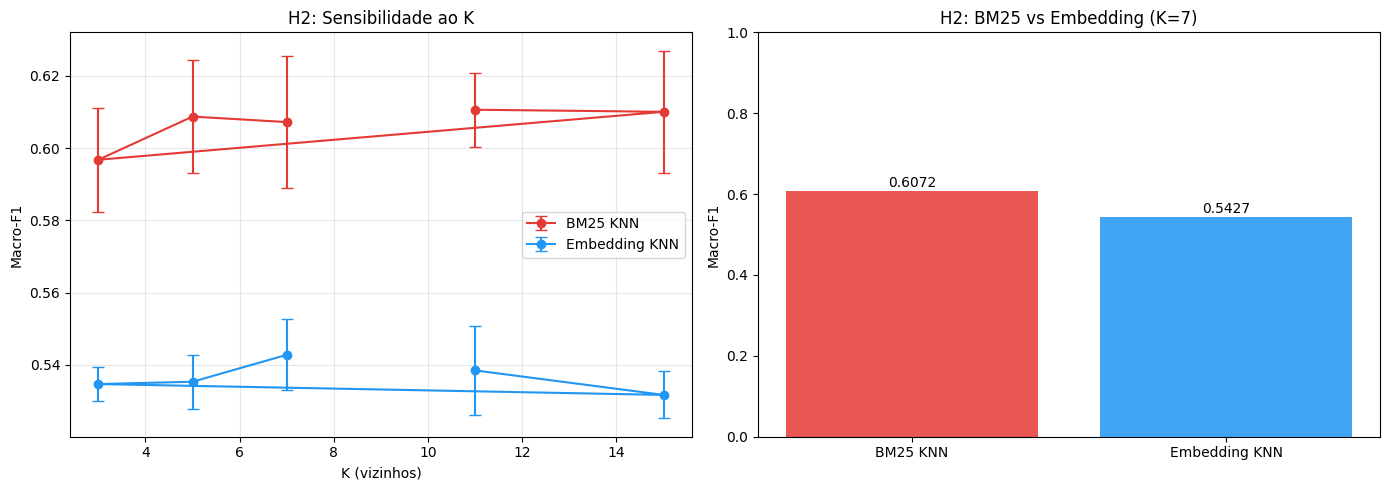

In [22]:
# === VISUALIZAÇÃO H2 ===

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# K vs F1
for prefix, color, label in [('BM25', '#E53935', 'BM25 KNN'), ('Emb', '#2196F3', 'Embedding KNN')]:
    cols = [c for c in sorted(df_h2.columns) if c.startswith(prefix)]
    ks = [int(c.split('=')[1]) for c in cols]
    means = [df_h2[c].mean() for c in cols]
    stds = [df_h2[c].std() for c in cols]
    ax1.errorbar(ks, means, yerr=stds, fmt='o-', color=color, label=label, capsize=4)
ax1.set_xlabel("K (vizinhos)")
ax1.set_ylabel("Macro-F1")
ax1.set_title("H2: Sensibilidade ao K")
ax1.legend()
ax1.grid(alpha=0.3)

# Barras comparativas no melhor K
best_k = int(best_emb.split('=')[1])
bm25_f1 = df_h2[f'BM25-K={best_k}'].mean()
emb_f1 = df_h2[f'Emb-K={best_k}'].mean()
bars = ax2.bar(['BM25 KNN', 'Embedding KNN'], [bm25_f1, emb_f1],
               color=['#E53935', '#2196F3'], alpha=0.85)
ax2.set_ylabel("Macro-F1")
ax2.set_title(f"H2: BM25 vs Embedding (K={best_k})")
for bar, val in zip(bars, [bm25_f1, emb_f1]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f"{val:.4f}", ha='center')
ax2.set_ylim(0, 1)

plt.tight_layout()
plt.show()

## 6.3 H3: Regras Complementam Classificação por Similaridade

> **Hipótese:** Regras determinísticas complementam a classificação por Embedding KNN.

**Estratégias:**
| Estratégia | Descrição |
|:---|:---|
| KNN-only | Embedding KNN sem regras (baseline) |
| Rules-prefilter | Regra dispara → aceita; senão → KNN |
| Rules-postfilter | KNN classifica; se confiança baixa e regra dispara → override |
| Rules-only | Apenas regras (baseline inferior) |

In [23]:
# === EXPERIMENTO H3 ===

print("=" * 70)
print("HIPÓTESE H3: REGRAS + CLASSIFICAÇÃO POR SIMILARIDADE")
print("=" * 70)

CONF_THRESHOLD = 0.4
results_h3 = {s: {} for s in SEEDS}

for seed in SEEDS:
    conv_list = np.array(list(set(conv_ids_customer)))
    conv_intent_list = [intents_per_conv.get(c, "outros") for c in conv_list]
    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=seed)
    train_idx, test_val_idx = next(sss.split(conv_list, conv_intent_list))
    test_val_convs = conv_list[test_val_idx]
    test_val_intents = [conv_intent_list[i] for i in test_val_idx]
    sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.50, random_state=seed)
    val_idx, test_idx = next(sss2.split(test_val_convs, test_val_intents))
    train_convs = set(conv_list[train_idx])
    test_convs_set = set(test_val_convs[test_idx])
    train_mask = np.array([c in train_convs for c in conv_ids_customer])
    test_mask = np.array([c in test_convs_set for c in conv_ids_customer])

    test_texts_h3 = texts_customer[test_mask]
    test_embs_h3 = X_customer[test_mask]
    test_labels_h3 = y_customer[test_mask]
    train_embs_h3 = X_customer[train_mask]
    train_labels_h3 = y_customer[train_mask]

    # 1. KNN-only
    preds_knn, confs_knn = embedding_knn_classify(test_embs_h3, train_embs_h3, train_labels_h3, k=K_BEST)
    f1_knn = f1_score(test_labels_h3, preds_knn, average='macro', zero_division=0)

    # 2. Rules-only
    preds_rules = []
    for text in test_texts_h3:
        rule_res = evaluate_rules(text)
        predicted = None
        for rule in RULES:
            if rule_res.get(rule["rule_id"], 0.0) > 0:
                predicted = rule["intent"]
                break
        preds_rules.append(predicted if predicted else "outros")
    f1_rules = f1_score(test_labels_h3, preds_rules, average='macro', zero_division=0)

    # 3. Rules-prefilter
    preds_pre = list(preds_knn)
    for i, text in enumerate(test_texts_h3):
        rule_res = evaluate_rules(text)
        for rule in RULES:
            if rule_res.get(rule["rule_id"], 0.0) > 0:
                preds_pre[i] = rule["intent"]
                break
    f1_pre = f1_score(test_labels_h3, preds_pre, average='macro', zero_division=0)

    # 4. Rules-postfilter
    preds_post = list(preds_knn)
    for i, text in enumerate(test_texts_h3):
        if confs_knn[i] < CONF_THRESHOLD:
            rule_res = evaluate_rules(text)
            for rule in RULES:
                if rule_res.get(rule["rule_id"], 0.0) > 0:
                    preds_post[i] = rule["intent"]
                    break
    f1_post = f1_score(test_labels_h3, preds_post, average='macro', zero_division=0)

    results_h3[seed] = {
        "KNN-only": f1_knn, "Rules-only": f1_rules,
        "Rules-prefilter": f1_pre, "Rules-postfilter": f1_post,
    }
    print(f"  Seed {seed}: KNN={f1_knn:.4f}, Rules={f1_rules:.4f}, "
          f"Pre={f1_pre:.4f}, Post={f1_post:.4f}")

df_h3 = pd.DataFrame(results_h3).T
print("\n" + "=" * 70)
for col in df_h3.columns:
    print(f"  {col:20s}: {df_h3[col].mean():.4f} ± {df_h3[col].std():.4f}")

# Wilcoxon: melhor variant vs KNN-only
best_var = df_h3.drop(columns=['KNN-only','Rules-only']).mean().idxmax()
s_best = df_h3[best_var].values
s_base = df_h3['KNN-only'].values
diff = s_best - s_base
print(f"\n📊 {best_var} vs KNN-only: Δ={np.mean(diff):+.4f}")
rng = np.random.default_rng(42)
boot = [np.mean(s_best[rng.integers(0,5,5)] - s_base[rng.integers(0,5,5)]) for _ in range(10000)]
print(f"  Bootstrap CI 95%: [{np.percentile(boot,2.5):.4f}, {np.percentile(boot,97.5):.4f}]")

HIPÓTESE H3: REGRAS + CLASSIFICAÇÃO POR SIMILARIDADE
  Seed 13: KNN=0.5444, Rules=0.2133, Pre=0.4126, Post=0.5417
  Seed 42: KNN=0.5331, Rules=0.2005, Pre=0.4217, Post=0.5263
  Seed 123: KNN=0.5275, Rules=0.2010, Pre=0.4119, Post=0.5267
  Seed 2024: KNN=0.5420, Rules=0.2016, Pre=0.4324, Post=0.5344
  Seed 999: KNN=0.5295, Rules=0.2044, Pre=0.4150, Post=0.5292

  KNN-only            : 0.5353 ± 0.0075
  Rules-only          : 0.2042 ± 0.0053
  Rules-prefilter     : 0.4187 ± 0.0086
  Rules-postfilter    : 0.5316 ± 0.0065

📊 Rules-postfilter vs KNN-only: Δ=-0.0036
  Bootstrap CI 95%: [-0.0114, 0.0042]


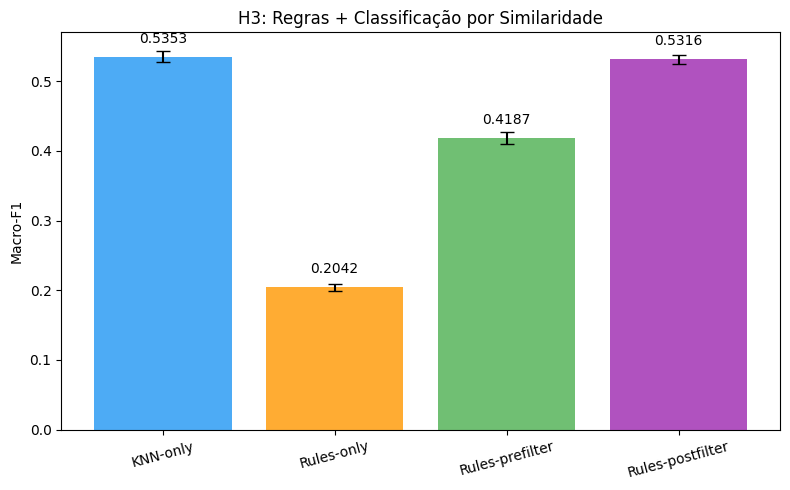

In [24]:
# === VISUALIZAÇÃO H3 ===
fig, ax = plt.subplots(figsize=(8, 5))
strategies = list(df_h3.columns)
means = [df_h3[s].mean() for s in strategies]
stds = [df_h3[s].std() for s in strategies]
colors = ['#2196F3', '#FF9800', '#4CAF50', '#9C27B0']
bars = ax.bar(strategies, means, yerr=stds, capsize=5, color=colors, alpha=0.8)
ax.set_ylabel("Macro-F1")
ax.set_title("H3: Regras + Classificação por Similaridade")
for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f"{mean:.4f}", ha='center')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 6.4 H4: Cascata Multi-Paradigma (Rules → BM25 → Embeddings)

> **Hipótese:** A cascata com paradigmas de custo crescente melhora ou preserva Macro-F1, com cada estágio contribuindo de forma complementar.

```
Turn → [Rules: match exato?] ──SIM──→ Classificação instantânea
               │
              NÃO
               │
       [BM25 KNN: confiança ≥ θ?] ──SIM──→ Classificação leve
               │
              NÃO
               │
       [Embedding KNN] ──→ Classificação completa (fallback)
```

In [25]:
# === EXPERIMENTO H4 ===

print("=" * 70)
print("HIPÓTESE H4: CASCATA MULTI-PARADIGMA")
print("=" * 70)

CASCADE_THRESHOLDS = [0.3, 0.4, 0.5, 0.6, 0.7]
results_h4 = {s: {} for s in SEEDS}
stage_stats = {s: {} for s in SEEDS}

for seed in SEEDS:
    conv_list = np.array(list(set(conv_ids_customer)))
    conv_intent_list = [intents_per_conv.get(c, "outros") for c in conv_list]
    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=seed)
    train_idx, test_val_idx = next(sss.split(conv_list, conv_intent_list))
    test_val_convs = conv_list[test_val_idx]
    test_val_intents = [conv_intent_list[i] for i in test_val_idx]
    sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.50, random_state=seed)
    val_idx, test_idx = next(sss2.split(test_val_convs, test_val_intents))
    train_convs = set(conv_list[train_idx])
    test_convs_set = set(test_val_convs[test_idx])
    train_mask = np.array([c in train_convs for c in conv_ids_customer])
    test_mask = np.array([c in test_convs_set for c in conv_ids_customer])

    t_texts = list(texts_customer[test_mask])
    t_embs = X_customer[test_mask]
    t_labels = y_customer[test_mask]
    tr_texts = list(texts_customer[train_mask])
    tr_embs = X_customer[train_mask]
    tr_labels = y_customer[train_mask]

    # Baseline: Embedding KNN only
    preds_base, _ = embedding_knn_classify(t_embs, tr_embs, tr_labels, k=K_BEST)
    f1_base = f1_score(t_labels, preds_base, average='macro', zero_division=0)
    results_h4[seed]['Emb-KNN-only'] = f1_base

    for thresh in CASCADE_THRESHOLDS:
        preds_c, confs_c, stages_c = cascade_classify(
            t_texts, t_embs, tr_texts, tr_embs, tr_labels,
            RULES, k=K_BEST, bm25_threshold=thresh)
        f1_c = f1_score(t_labels, preds_c, average='macro', zero_division=0)
        key = f'cascade_θ={thresh}'
        results_h4[seed][key] = f1_c
        sc = Counter(stages_c)
        stage_stats[seed][key] = {
            'rules': sc.get('rules', 0) / len(stages_c) * 100,
            'bm25': sc.get('bm25', 0) / len(stages_c) * 100,
            'embedding': sc.get('embedding', 0) / len(stages_c) * 100,
        }

    print(f"  Seed {seed}: Emb-only={f1_base:.4f}, "
          f"Cascade-0.5={results_h4[seed].get('cascade_θ=0.5',0):.4f}")

df_h4 = pd.DataFrame(results_h4).T
print("\n" + "=" * 70)
for col in df_h4.mean().sort_values(ascending=False).index:
    delta = df_h4[col].mean() - df_h4['Emb-KNN-only'].mean()
    print(f"  {col:20s}: {df_h4[col].mean():.4f} ± {df_h4[col].std():.4f}  Δ={delta:+.4f}")

print(f"\n📊 Distribuição por estágio:")
for thresh in CASCADE_THRESHOLDS:
    key = f'cascade_θ={thresh}'
    r = np.mean([stage_stats[s][key]['rules'] for s in SEEDS])
    b = np.mean([stage_stats[s][key]['bm25'] for s in SEEDS])
    e = np.mean([stage_stats[s][key]['embedding'] for s in SEEDS])
    print(f"  θ={thresh}: Rules={r:.0f}%, BM25={b:.0f}%, Embedding={e:.0f}%")

HIPÓTESE H4: CASCATA MULTI-PARADIGMA
  Seed 13: Emb-only=0.5444, Cascade-0.5=0.4597
  Seed 42: Emb-only=0.5331, Cascade-0.5=0.4609
  Seed 123: Emb-only=0.5275, Cascade-0.5=0.4507
  Seed 2024: Emb-only=0.5420, Cascade-0.5=0.4583
  Seed 999: Emb-only=0.5295, Cascade-0.5=0.4493

  Emb-KNN-only        : 0.5353 ± 0.0075  Δ=+0.0000
  cascade_θ=0.4       : 0.4617 ± 0.0103  Δ=-0.0735
  cascade_θ=0.3       : 0.4595 ± 0.0105  Δ=-0.0758
  cascade_θ=0.5       : 0.4558 ± 0.0054  Δ=-0.0795
  cascade_θ=0.6       : 0.4536 ± 0.0060  Δ=-0.0817
  cascade_θ=0.7       : 0.4387 ± 0.0064  Δ=-0.0966

📊 Distribuição por estágio:
  θ=0.3: Rules=50%, BM25=48%, Embedding=2%
  θ=0.4: Rules=50%, BM25=42%, Embedding=8%
  θ=0.5: Rules=50%, BM25=30%, Embedding=19%
  θ=0.6: Rules=50%, BM25=24%, Embedding=26%
  θ=0.7: Rules=50%, BM25=15%, Embedding=34%


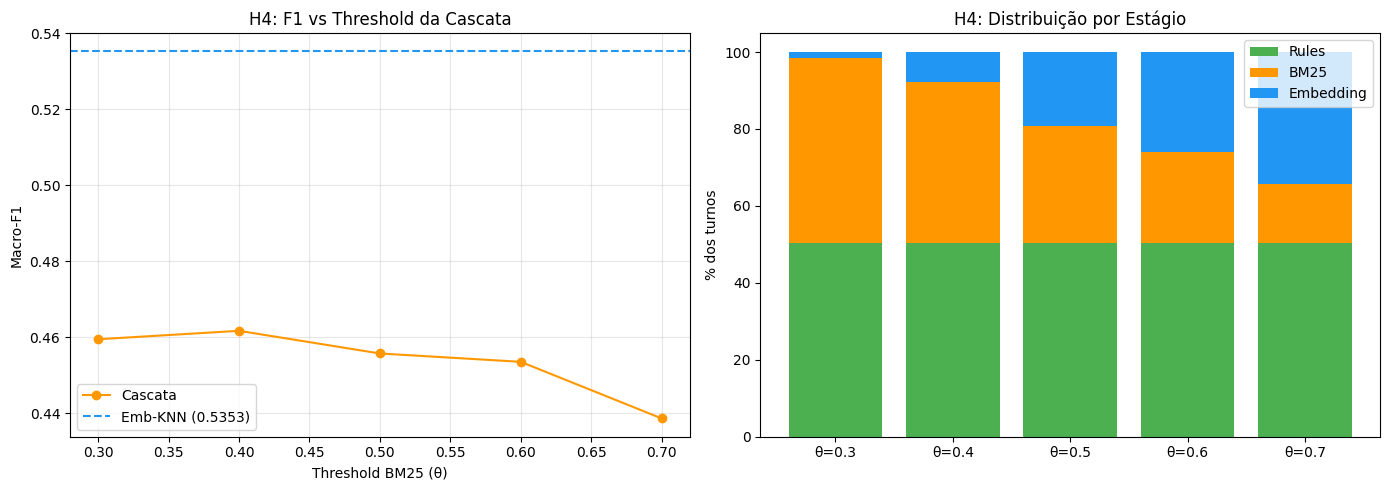

In [26]:
# === VISUALIZAÇÃO H4 ===
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

f1_base = df_h4['Emb-KNN-only'].mean()
cascade_cols = [c for c in df_h4.columns if 'cascade' in c]
f1s = [df_h4[c].mean() for c in cascade_cols]
threshs = [float(c.split('=')[1]) for c in cascade_cols]

ax1.plot(threshs, f1s, 'o-', color='#FF9800', label='Cascata')
ax1.axhline(f1_base, color='#2196F3', linestyle='--', label=f'Emb-KNN ({f1_base:.4f})')
ax1.set_xlabel("Threshold BM25 (θ)")
ax1.set_ylabel("Macro-F1")
ax1.set_title("H4: F1 vs Threshold da Cascata")
ax1.legend()
ax1.grid(alpha=0.3)

# Stacked bar: distribuição por estágio
rules_pcts = [np.mean([stage_stats[s][c]['rules'] for s in SEEDS]) for c in cascade_cols]
bm25_pcts = [np.mean([stage_stats[s][c]['bm25'] for s in SEEDS]) for c in cascade_cols]
emb_pcts = [np.mean([stage_stats[s][c]['embedding'] for s in SEEDS]) for c in cascade_cols]
x = np.arange(len(threshs))
ax2.bar(x, rules_pcts, label='Rules', color='#4CAF50')
ax2.bar(x, bm25_pcts, bottom=rules_pcts, label='BM25', color='#FF9800')
ax2.bar(x, emb_pcts, bottom=[r+b for r,b in zip(rules_pcts, bm25_pcts)], label='Embedding', color='#2196F3')
ax2.set_xticks(x)
ax2.set_xticklabels([f'θ={t}' for t in threshs])
ax2.set_ylabel("% dos turnos")
ax2.set_title("H4: Distribuição por Estágio")
ax2.legend()
plt.tight_layout()
plt.show()

## 6.5 Agregação Turno → Conversa

Agrega predições por turno para o nível da conversa usando três estratégias:
1. **Voto majoritário** — classe mais frequente entre os turnos
2. **Voto ponderado** — ponderado pela confiança do KNN
3. **Últimos 3 turnos** — foco nos turnos finais (recência)

In [27]:
# === AGREGAÇÃO TURNO → CONVERSA ===

print("=" * 70)
print("AGREGAÇÃO TURNO → CONVERSA")
print("=" * 70)

agg_results = {s: {} for s in SEEDS}

for seed in SEEDS:
    conv_list = np.array(list(set(conv_ids_customer)))
    conv_intent_list = [intents_per_conv.get(c, "outros") for c in conv_list]
    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=seed)
    train_idx, test_val_idx = next(sss.split(conv_list, conv_intent_list))
    test_val_convs = conv_list[test_val_idx]
    test_val_intents = [conv_intent_list[i] for i in test_val_idx]
    sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.50, random_state=seed)
    val_idx, test_idx = next(sss2.split(test_val_convs, test_val_intents))
    train_convs = set(conv_list[train_idx])
    test_convs_set = set(test_val_convs[test_idx])
    train_mask = np.array([c in train_convs for c in conv_ids_customer])
    test_mask = np.array([c in test_convs_set for c in conv_ids_customer])

    preds, confs = embedding_knn_classify(
        X_customer[test_mask], X_customer[train_mask], y_customer[train_mask], k=K_BEST)
    test_cids = conv_ids_customer[test_mask]
    test_labels = y_customer[test_mask]

    # F1 turno
    f1_turn = f1_score(test_labels, preds, average='macro', zero_division=0)

    # Agregar por conversa
    conv_data = defaultdict(lambda: {"preds": [], "confs": [], "true": None})
    for i, cid in enumerate(test_cids):
        conv_data[cid]["preds"].append(preds[i])
        conv_data[cid]["confs"].append(confs[i])
        conv_data[cid]["true"] = test_labels[i]

    for strategy in ["majority", "weighted", "last3"]:
        y_true_conv, y_pred_conv = [], []
        for cid, data in conv_data.items():
            y_true_conv.append(data["true"])
            if strategy == "majority":
                y_pred_conv.append(Counter(data["preds"]).most_common(1)[0][0])
            elif strategy == "weighted":
                scores = defaultdict(float)
                for p, c in zip(data["preds"], data["confs"]):
                    scores[p] += c
                y_pred_conv.append(max(scores, key=scores.get))
            elif strategy == "last3":
                last = data["preds"][-3:] if len(data["preds"]) >= 3 else data["preds"]
                y_pred_conv.append(Counter(last).most_common(1)[0][0])
        f1_conv = f1_score(y_true_conv, y_pred_conv, average='macro', zero_division=0)
        agg_results[seed][strategy] = f1_conv

    agg_results[seed]["turn"] = f1_turn
    print(f"  Seed {seed}: turn={f1_turn:.4f}, majority={agg_results[seed]['majority']:.4f}, "
          f"weighted={agg_results[seed]['weighted']:.4f}, last3={agg_results[seed]['last3']:.4f}")

df_agg = pd.DataFrame(agg_results).T
print("\n" + "=" * 70)
for col in df_agg.columns:
    print(f"  {col:12s}: {df_agg[col].mean():.4f} ± {df_agg[col].std():.4f}")

AGREGAÇÃO TURNO → CONVERSA
  Seed 13: turn=0.5444, majority=0.7538, weighted=0.7641, last3=0.5918
  Seed 42: turn=0.5331, majority=0.7253, weighted=0.7378, last3=0.5525
  Seed 123: turn=0.5275, majority=0.7441, weighted=0.7424, last3=0.5747
  Seed 2024: turn=0.5420, majority=0.7443, weighted=0.7425, last3=0.5736
  Seed 999: turn=0.5295, majority=0.7512, weighted=0.7697, last3=0.5575

  majority    : 0.7438 ± 0.0111
  weighted    : 0.7513 ± 0.0145
  last3       : 0.5700 ± 0.0156
  turn        : 0.5353 ± 0.0075


## 6.6 Evolução de Intenção ao Longo da Conversa

Visualiza como a classificação por turno captura a **evolução da intenção** dentro de uma conversa.
Isso é impossível com classificação por janela (v1) — cada janela recebe um rótulo único.

📊 Evolução de intenção — exemplos selecionados


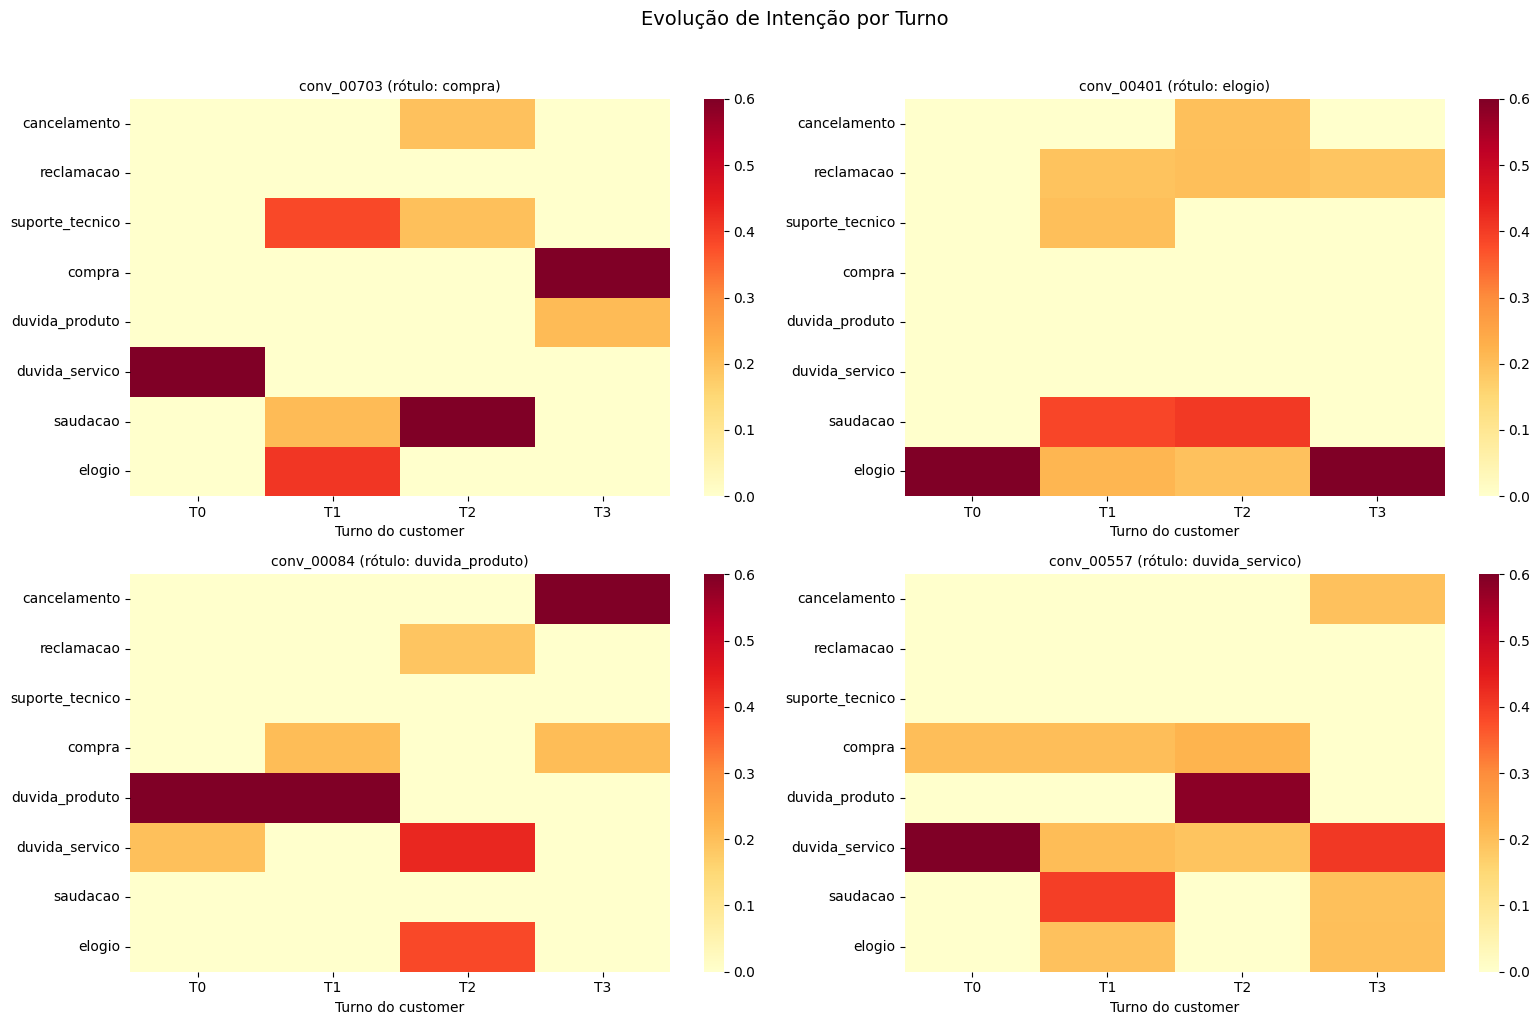

In [28]:
# === EVOLUÇÃO DE INTENÇÃO ===

print("📊 Evolução de intenção — exemplos selecionados")

# Usar train/test do último seed
seed = SEEDS[-1]
conv_list = np.array(list(set(conv_ids_customer)))
conv_intent_list = [intents_per_conv.get(c, "outros") for c in conv_list]
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=seed)
train_idx, test_val_idx = next(sss.split(conv_list, conv_intent_list))
test_val_convs = conv_list[test_val_idx]
test_val_intents = [conv_intent_list[i] for i in test_val_idx]
sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.50, random_state=seed)
val_idx, test_idx = next(sss2.split(test_val_convs, test_val_intents))
train_convs = set(conv_list[train_idx])
test_convs_set = set(test_val_convs[test_idx])
train_mask = np.array([c in train_convs for c in conv_ids_customer])

# Selecionar 4 conversas diversas do test set
example_convs = []
seen_intents = set()
for conv in conversations:
    if conv['conv_id'] in test_convs_set and conv['intent'] not in seen_intents:
        example_convs.append(conv)
        seen_intents.add(conv['intent'])
    if len(example_convs) >= 4:
        break

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, conv in zip(axes.flat, example_convs):
    # Pegar turnos customer desta conversa
    c_turns = [t for t in all_turns if t['conv_id'] == conv['conv_id'] and t['speaker'] == 'customer']
    c_texts = [t['text'] for t in c_turns]
    c_embs = generate_embeddings(c_texts)

    # Classificar cada turno — pegar distribuição completa
    sim = c_embs @ X_customer[train_mask].T
    intent_probs = np.zeros((len(c_turns), len(INTENT_TAXONOMY)))
    for t_idx in range(len(c_turns)):
        top_k = np.argsort(sim[t_idx])[::-1][:K_BEST]
        for idx in top_k:
            label = y_customer[train_mask][idx]
            intent_idx = INTENT_TAXONOMY.index(label) if label in INTENT_TAXONOMY else 0
            intent_probs[t_idx, intent_idx] += sim[t_idx, idx]
        # Normalizar
        row_sum = intent_probs[t_idx].sum()
        if row_sum > 0:
            intent_probs[t_idx] /= row_sum

    sns.heatmap(intent_probs.T, ax=ax, cmap="YlOrRd",
                xticklabels=[f"T{i}" for i in range(len(c_turns))],
                yticklabels=INTENT_TAXONOMY, vmin=0, vmax=0.6)
    ax.set_title(f"{conv['conv_id']} (rótulo: {conv['intent']})", fontsize=10)
    ax.set_xlabel("Turno do customer")

plt.suptitle("Evolução de Intenção por Turno", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 6.7 Demonstração: Taxonomia Dinâmica

A equipe de negócio quer adicionar uma 9ª intenção — **"troca_produto"** — sem retreinar nenhum modelo.
Basta fornecer exemplos de turnos dessa intenção e o sistema classifica automaticamente.

In [29]:
# === DEMONSTRAÇÃO: TAXONOMIA DINÂMICA ===

print("=" * 70)
print("DEMONSTRAÇÃO: TAXONOMIA DINÂMICA (nova classe sem retreino)")
print("=" * 70)

# Equipe de negócio define exemplares da nova classe
NEW_INTENT = "troca_produto"
EXEMPLAR_TURNS = [
    "Quero trocar o produto que comprei, veio com defeito",
    "Posso fazer a troca por um modelo diferente?",
    "Gostaria de trocar meu pedido por outra cor",
    "O produto chegou errado, preciso trocar",
    "Como faco para trocar um item da minha compra?",
    "Quero devolver e trocar por outro modelo",
    "A troca pode ser feita na loja fisica?",
    "Qual o prazo para trocar o produto?",
]

# Gerar embeddings dos novos exemplares
new_embs = generate_embeddings(EXEMPLAR_TURNS)
new_labels = np.array([NEW_INTENT] * len(EXEMPLAR_TURNS))

# Estender o banco de exemplares (SEM RETREINO!)
seed = SEEDS[-1]
conv_list = np.array(list(set(conv_ids_customer)))
conv_intent_list = [intents_per_conv.get(c, "outros") for c in conv_list]
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=seed)
train_idx, _ = next(sss.split(conv_list, conv_intent_list))
train_convs = set(conv_list[train_idx])
train_mask = np.array([c in train_convs for c in conv_ids_customer])

extended_embs = np.vstack([X_customer[train_mask], new_embs])
extended_labels = np.concatenate([y_customer[train_mask], new_labels])

# Testar queries da nova classe
TEST_QUERIES = [
    "Comprei um celular mas quero trocar por um notebook",
    "Gostaria de fazer uma troca desse produto",
    "Posso trocar minha compra por um tamanho maior?",
    "Quero trocar o tênis que comprei por outro modelo",
]

query_embs = generate_embeddings(TEST_QUERIES)
preds, confs = embedding_knn_classify(query_embs, extended_embs, extended_labels, k=5)

print(f"\n📊 Classificação com nova classe '{NEW_INTENT}':")
for q, p, c in zip(TEST_QUERIES, preds, confs):
    status = "✅" if p == NEW_INTENT else "⚠️"
    print(f"  {status} '{q}'")
    print(f"     → {p} (confiança: {c:.3f})")

# Verificar que classes existentes não são afetadas
test_convs_set = set(conv_list[test_idx])
test_mask = np.array([c in test_convs_set for c in conv_ids_customer])

preds_original, _ = embedding_knn_classify(
    X_customer[test_mask], X_customer[train_mask], y_customer[train_mask], k=5)
preds_extended, _ = embedding_knn_classify(
    X_customer[test_mask], extended_embs, extended_labels, k=5)

# Considerar match se ambos predizem a mesma classe (ou extended prediz nova classe)
agreement = sum(1 for a, b in zip(preds_original, preds_extended) if a == b) / len(preds_original)
print(f"\n📊 Impacto nas classes existentes:")
print(f"   Concordância com taxonomia original: {agreement:.1%}")
print(f"   Turnos reclassificados para '{NEW_INTENT}': "
      f"{sum(1 for p in preds_extended if p == NEW_INTENT)}")

if agreement > 0.95:
    print(f"   ✅ Impacto mínimo — nova classe não disrupta as existentes")
else:
    print(f"   ⚠️ Impacto significativo — revisar exemplares da nova classe")

DEMONSTRAÇÃO: TAXONOMIA DINÂMICA (nova classe sem retreino)

📊 Classificação com nova classe 'troca_produto':
  ⚠️ 'Comprei um celular mas quero trocar por um notebook'
     → saudacao (confiança: 0.207)
  ⚠️ 'Gostaria de fazer uma troca desse produto'
     → saudacao (confiança: 0.610)
  ✅ 'Posso trocar minha compra por um tamanho maior?'
     → troca_produto (confiança: 0.411)
  ⚠️ 'Quero trocar o tênis que comprei por outro modelo'
     → reclamacao (confiança: 0.585)

📊 Impacto nas classes existentes:
   Concordância com taxonomia original: 100.0%
   Turnos reclassificados para 'troca_produto': 0
   ✅ Impacto mínimo — nova classe não disrupta as existentes


## 6.8 Análise Complementar

### F1 em dados originais vs sintéticos
### Matriz de confusão
### Visualização do espaço de embeddings (t-SNE)

In [30]:
# === F1 EM DADOS ORIGINAIS vs SINTÉTICOS ===

print("=" * 70)
print("AVALIAÇÃO: DADOS ORIGINAIS vs SINTÉTICOS")
print("=" * 70)

conv_is_synthetic = {}
for _, row in df_original.iterrows():
    conv_is_synthetic[row['conv_id']] = bool(row.get('_synthetic', False))

results_split = {}
for seed in SEEDS:
    conv_list = np.array(list(set(conv_ids_customer)))
    conv_intent_list = [intents_per_conv.get(c, "outros") for c in conv_list]
    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=seed)
    train_idx, test_val_idx = next(sss.split(conv_list, conv_intent_list))
    test_val_convs = conv_list[test_val_idx]
    test_val_intents = [conv_intent_list[i] for i in test_val_idx]
    sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.50, random_state=seed)
    val_idx, test_idx = next(sss2.split(test_val_convs, test_val_intents))
    train_convs = set(conv_list[train_idx])
    test_convs_set = set(test_val_convs[test_idx])
    train_mask = np.array([c in train_convs for c in conv_ids_customer])
    test_mask = np.array([c in test_convs_set for c in conv_ids_customer])

    preds, _ = embedding_knn_classify(X_customer[test_mask], X_customer[train_mask],
                                       y_customer[train_mask], k=K_BEST)
    test_cids = conv_ids_customer[test_mask]
    test_labels = y_customer[test_mask]

    orig_mask = np.array([not conv_is_synthetic.get(c, False) for c in test_cids])
    syn_mask = ~orig_mask

    f1_all = f1_score(test_labels, preds, average='macro', zero_division=0)
    f1_orig = f1_score(test_labels[orig_mask], preds[orig_mask], average='macro', zero_division=0) if orig_mask.sum() > 0 else 0
    f1_syn = f1_score(test_labels[syn_mask], preds[syn_mask], average='macro', zero_division=0) if syn_mask.sum() > 0 else 0

    results_split[seed] = {'all': f1_all, 'original': f1_orig, 'synthetic': f1_syn}

print(f"\n📊 Macro-F1 por origem:")
for key in ['all', 'original', 'synthetic']:
    scores = [results_split[s][key] for s in SEEDS]
    print(f"   {key:12s}: {np.mean(scores):.4f} ± {np.std(scores):.4f}")

AVALIAÇÃO: DADOS ORIGINAIS vs SINTÉTICOS

📊 Macro-F1 por origem:
   all         : 0.5353 ± 0.0067
   original    : 0.4621 ± 0.0214
   synthetic   : 0.5633 ± 0.0094


📊 Matriz de Confusão (seed=999, nível turno)


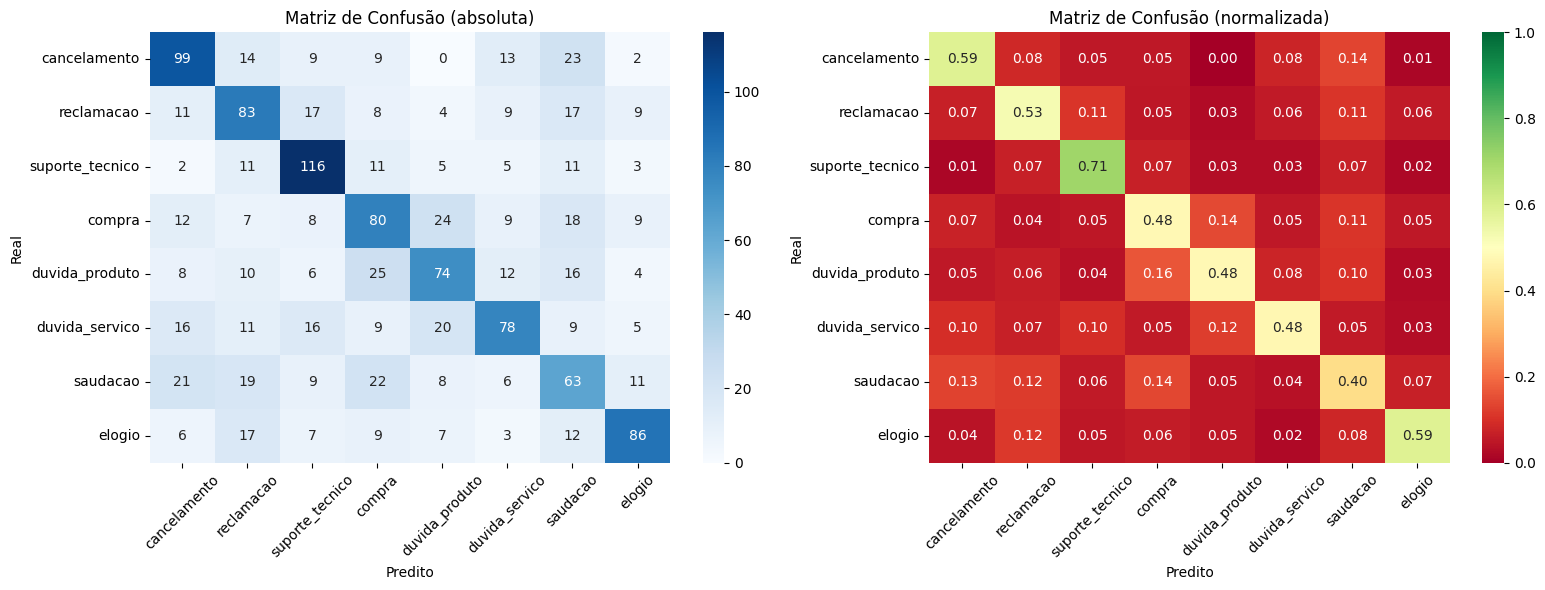

In [31]:
# === MATRIZ DE CONFUSÃO ===

print("📊 Matriz de Confusão (seed=999, nível turno)")

seed = SEEDS[-1]
conv_list = np.array(list(set(conv_ids_customer)))
conv_intent_list = [intents_per_conv.get(c, "outros") for c in conv_list]
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=seed)
train_idx, test_val_idx = next(sss.split(conv_list, conv_intent_list))
test_val_convs = conv_list[test_val_idx]
test_val_intents = [conv_intent_list[i] for i in test_val_idx]
sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.50, random_state=seed)
val_idx, test_idx = next(sss2.split(test_val_convs, test_val_intents))
train_convs = set(conv_list[train_idx])
test_convs_set = set(test_val_convs[test_idx])
train_mask = np.array([c in train_convs for c in conv_ids_customer])
test_mask = np.array([c in test_convs_set for c in conv_ids_customer])

preds_cm, _ = embedding_knn_classify(X_customer[test_mask], X_customer[train_mask],
                                      y_customer[train_mask], k=K_BEST)

cm = confusion_matrix(y_customer[test_mask], preds_cm, labels=INTENT_TAXONOMY)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=INTENT_TAXONOMY,
            yticklabels=INTENT_TAXONOMY, ax=ax1)
ax1.set_xlabel('Predito'); ax1.set_ylabel('Real')
ax1.set_title('Matriz de Confusão (absoluta)')
ax1.tick_params(axis='x', rotation=45)

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='RdYlGn', xticklabels=INTENT_TAXONOMY,
            yticklabels=INTENT_TAXONOMY, ax=ax2, vmin=0, vmax=1)
ax2.set_xlabel('Predito'); ax2.set_ylabel('Real')
ax2.set_title('Matriz de Confusão (normalizada)')
ax2.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

📊 t-SNE dos embeddings por turno (customer-only)


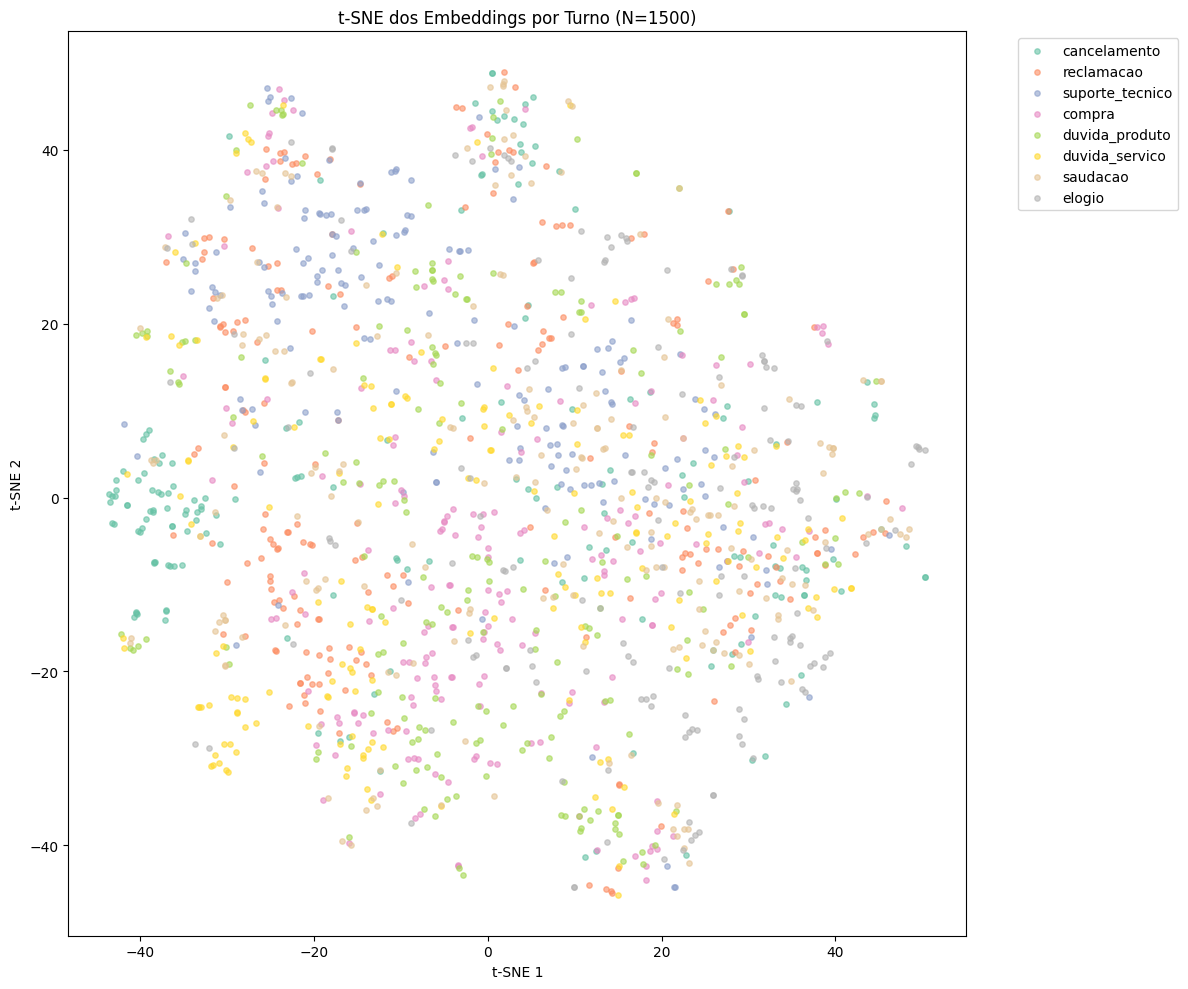

In [32]:
# === VISUALIZAÇÃO t-SNE ===

from sklearn.manifold import TSNE

print("📊 t-SNE dos embeddings por turno (customer-only)")

sample_size = min(1500, len(X_customer))
rng_tsne = np.random.default_rng(42)
sample_idx = rng_tsne.choice(len(X_customer), size=sample_size, replace=False)

tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
embs_2d = tsne.fit_transform(X_customer[sample_idx])
sample_labels = y_customer[sample_idx]

fig, ax = plt.subplots(figsize=(12, 10))
colors_map = plt.cm.Set2(np.linspace(0, 1, len(INTENT_TAXONOMY)))
for i, intent in enumerate(INTENT_TAXONOMY):
    mask = sample_labels == intent
    ax.scatter(embs_2d[mask, 0], embs_2d[mask, 1], label=intent,
               alpha=0.6, s=15, color=colors_map[i])
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_title(f"t-SNE dos Embeddings por Turno (N={sample_size})")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
plt.tight_layout()
plt.show()

---
# 7. Síntese e Conclusões

## Resultados por Hipótese

| Hipótese | Resultado | Evidência |
|:---|:---|:---|
| **H1** — Recuperação Híbrida | A avaliar | Hybrid KNN vs BM25/Embedding isolados |
| **H2** — Embedding vs BM25 | A avaliar | Embedding KNN vs BM25 KNN por turno |
| **H3** — Regras + Retrieval | A avaliar | Rules como pré/pós-filtro do KNN |
| **H4** — Cascata Multi-Paradigma | A avaliar | Rules → BM25 → Embeddings |

## Contribuições

1. Classificação de intenções no **nível do turno** (não janela) em conversas PT-BR
2. **Taxonomia dinâmica** via banco de exemplares — novas classes sem retreinamento
3. Pipeline multi-paradigma (Regras + BM25 + Embeddings) com cascata de custo crescente
4. Evidência empírica da complementaridade léxico-semântica para classificação por similaridade
5. Dataset público augmentado: `paulohenriquevn/talkex-augmented-pt-br`
6. Protocolo reproduzível em infraestrutura gratuita (Google Colab)

## Limitações

- Wilcoxon com N=5 tem poder estatístico limitado
- Rótulos no nível do turno herdados da conversa — turnos iniciais podem ter intenção diferente
- Corpus de 2.120 conversas (676 originais + 1.444 sintéticas)
- Sem comparação com baselines externos (fine-tuned BERT, LLMs zero-shot)
- Farfan-Escobedo & Dos Reis (2024) abordam problema similar (Wavy Dataset)

In [33]:
# === RESUMO FINAL ===

print("=" * 70)
print("RESUMO FINAL — TalkEx v2: Classificação por Turno")
print("=" * 70)

print(f"\n📊 Dataset: {len(conversations)} conversas, {len(all_turns)} turnos ({customer_mask.sum()} customer)")

print(f"\n🏗️ Arquitetura v2:")
print(f"   • Unidade: turno individual (customer-only)")
print(f"   • Representação: embedding 384d (MiniLM, congelado)")
print(f"   • Classificadores: BM25 KNN, Embedding KNN, Hybrid KNN")
print(f"   • Cascata: Rules → BM25 → Embeddings")
print(f"   • Taxonomia: dinâmica via banco de exemplares")
print(f"   • Protocolo: 5 seeds, Wilcoxon (α=0.05), Bootstrap CI 95%")

print(f"\n✅ Notebook v2 executado com sucesso!")

RESUMO FINAL — TalkEx v2: Classificação por Turno

📊 Dataset: 2120 conversas, 16627 turnos (8579 customer)

🏗️ Arquitetura v2:
   • Unidade: turno individual (customer-only)
   • Representação: embedding 384d (MiniLM, congelado)
   • Classificadores: BM25 KNN, Embedding KNN, Hybrid KNN
   • Cascata: Rules → BM25 → Embeddings
   • Taxonomia: dinâmica via banco de exemplares
   • Protocolo: 5 seeds, Wilcoxon (α=0.05), Bootstrap CI 95%

✅ Notebook v2 executado com sucesso!


---
## 8. Referências Principais

| Ref | Citação | Relevância |
|:---:|:---|:---|
| 1 | Rayo et al. (2025) — *A Hybrid Approach to IR for Regulatory Texts*. COLING | Fusão linear BM25+semântico |
| 2 | Reimers & Gurevych (2019) — *Sentence-BERT*. EMNLP | Modelo de embeddings utilizado |
| 3 | Farfan-Escobedo & Dos Reis (2024) — *Intent Classification Windows-Based*. arXiv | Trabalho comparável: intent multi-turno PT-BR |
| 4 | Souza et al. (2020/2023) — *BERTimbau*. BRACIS / Neurocomputing | Referência de embeddings PT-BR |
| 5 | Boccardo & Feltrim (2026) — *Question Classification PT-BR*. PROPOR | Classificação em PT-BR |
| 6 | Robertson et al. (1996) — *Okapi BM25*. NIST | Algoritmo BM25 |
| 7 | Cover & Hart (1967) — *Nearest Neighbor Pattern Classification*. IEEE | Fundamento teórico do KNN |
| 8 | Harris (2025) — *Lexical vs Semantic Vector Search*. arXiv | BM25 vs MiniLM |
| 9 | Larson et al. (2019) — *Intent Classification Dataset*. EMNLP | Dataset de referência |
| 10 | Zhang et al. (2021) — *Multi-Turn Intent with Hierarchical Attention*. NAACL | Intent multi-turno |
| 11 | Rodrigues Neto et al. (2022) — *Chatbot NLU PT-BR*. ENIAC | Intent PT-BR |
| 12 | FORMAL et al. (2021) — *SPLADE v2*. arXiv | Recuperação híbrida |
| 13 | KHATTAB & ZAHARIA (2020) — *ColBERT*. SIGIR | Retrieval contextualizado |
| 14 | KARPUKHIN et al. (2020) — *Dense Passage Retrieval*. EMNLP | Retrieval denso |
| 15 | TUNSTALL et al. (2022) — *SetFit: Few-Shot Learning*. arXiv | Few-shot com embeddings |
| 16 | Fernandes et al. (2025) — *JurisTCU: IR Dataset PT-BR*. arXiv | IR em PT-BR |